# DAY 2 · 모델 개발 및 평가

Batch 1 학습 → Batch 2 평가. 회귀 전략과 성능·오류·ESS 해석을 평가항목에 맞춰 연결했습니다. 이 노트북에는 실행으로 생성한 결과를 포함합니다.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/train.py').exists() and (p / 'archive').exists())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
OUT = ROOT / 'DAY2/results'
print('결과 경로:', OUT)

결과 경로: /Users/skala/Desktop/SKALA/SKALA-dev/24_데이터분석_미니프로젝트/DAY2/results


## 1. EDA → 모델 전략

| EDA에서 확인한 사실 | 전략과 구현 | 검증 방법 |
| --- | --- | --- |
| ΔQ log 분산–log 수명 Pearson r=-0.844 | `log10 Var(Q100−Q10)`를 모든 후보에 포함 | 단일 피처 Linear 기준선과 비교 |
| ΔQ 분산·최솟값·평균의 상관 절댓값 ≥0.97 | 중복 피처를 동시에 넣지 않음 | 대표 5개 피처의 16개 부분집합 비교 |
| 용량 기울기 r=0.552, 초기 충전 시간 r=0.575 | 기울기(2–100회)와 평균 충전 시간(2–6회) 추가 | 개발 CV에서 추가 피처 효과 비교 |
| 온도·IR의 직접 관계가 약하고 센서 영향 가능 | 보조 피처로 포함·제외 | 대표 피처의 모든 부분집합 비교 |
| Batch 1 유효 표본 36셀, 정책 20개 | 소수 피처 + Ridge/Elastic Net 정규화 | 프로토콜 단위 nested GroupKFold |
| Batch 1에는 <500회 셀이 없음 | 이진 분류 대신 연속 수명 회귀 선택 | 원 단위 MAPE·MAE·RMSE |
| 조기 종료·후속 기록 10셀의 목표값 불완전 | 원본은 보존하고 10셀 제외 | 셀별 audit 및 DAY 1 분할표 대조 |

Batch 1 최소 수명 534회, <500회 셀 0개이므로 회귀를 선택합니다. 후반 knee·최종 용량·관측 길이는 입력에서 제외합니다. DAY 1이 세 배치 전체를 본 탐색이라는 점은 내부 검증 해석의 한계입니다.


DAY 1과 같은 **단수명 <500회 / 중간 500–1,000회 / 장수명 >1,000회** 기준을 유지합니다. 분모는 모델링에 사용할 유효 라벨 셀이며 알려진 불완전·결측 라벨은 제외했습니다. 그룹이 없는 배치는 0셀로 표시하고 경계를 바꾸어 채우지 않습니다. 이 기준은 아래 EDA·회귀 오류 분석과 추가 3분류 라벨에 사용합니다. 회귀 입력에는 실제 수명 그룹을 넣지 않습니다. 원논문의 장·단수명 이진 기준(550회)은 추가 개발·비교 절에서 별도로 분석합니다.



### 1. Cycle Life 분포

수명 통계의 단위는 사이클 수입니다.

| Batch | 유효 셀 수 | 최소 | 중앙값 | 평균 | 표준편차 | 최대 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 36 | 534.000 | 772.500 | 788.417 | 148.696 | 1074.000 |
| 2 | 39 | 392.000 | 472.000 | 565.744 | 222.202 | 1186.000 |
| 3 | 44 | 541.000 | 1005.500 | 1059.659 | 313.870 | 1935.000 |

| Batch | 분모 (셀) | 단수명 <500 | 중간 500–1,000 | 장수명 >1,000 |
| --- | --- | --- | --- | --- |
| 1 | 36 | 0셀 (0.0%) | 31셀 (86.1%) | 5셀 (13.9%) |
| 2 | 39 | 28셀 (71.8%) | 8셀 (20.5%) | 3셀 (7.7%) |
| 3 | 44 | 0셀 (0.0%) | 21셀 (47.7%) | 23셀 (52.3%) |


Batch 1은 중간 수명에 집중되고 <500회 셀이 없습니다. Batch 2는 28/39셀(71.8%)이 <500회이고 소수의 긴 수명 셀 때문에 오른쪽 꼬리가 나타납니다. Batch 3은 더 넓은 범위로 분포하며 장수명 비중이 큽니다. 위 Batch 2 그래프는 고정 모델 평가 후의 사후 진단으로 후보 선택에 사용하지 않았습니다.

**핵심 발견:** 학습 배치에 없는 단수명 구간이 외부 Batch 2의 대부분을 차지하므로 단수명 개발 데이터 확보와 배치 간 일반화 검증이 중요합니다.



In [2]:
pd.read_csv(OUT / 'eda_distribution.csv')

batch,n_cells,min,q25,median,mean,std,q75,max,skewness,short_lt500,long_gt1000
1,36,534.000,681.000,772.500,788.417,148.696,871.500,1074.000,0.300,0,5
2,39,392.000,439.500,472.000,565.744,222.202,508.500,1186.000,1.637,28,3
3,44,541.000,828.000,1005.500,1059.659,313.870,1155.250,1935.000,1.255,0,23


In [3]:
pd.read_csv(OUT / 'life_group_proportions.csv')

batch,life_group,n_cells,batch_n_cells,proportion_pct
1,short_lt500,0,36,0.000
1,middle_500_1000,31,36,86.111
1,long_gt1000,5,36,13.889
2,short_lt500,28,39,71.795
2,middle_500_1000,8,39,20.513
2,long_gt1000,3,39,7.692
3,short_lt500,0,44,0.000
3,middle_500_1000,21,44,47.727
3,long_gt1000,23,44,52.273


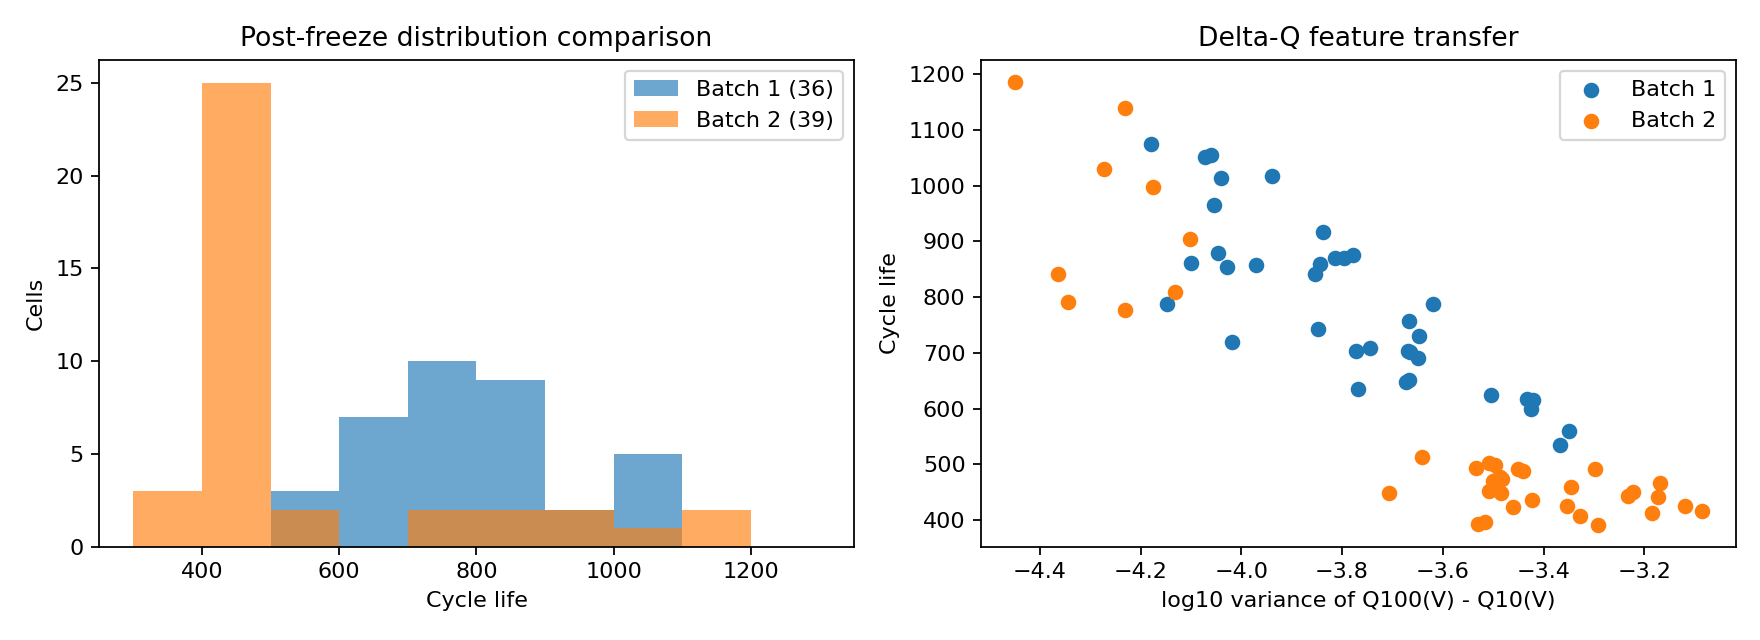

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '03_batch_shift.png'))
plt.axis('off')
plt.show()

### 2. 열화 곡선 분석


왼쪽은 수명순으로 정렬한 각 그룹의 아래쪽 중앙 셀을 선택한 실제 곡선입니다. 곡선 모양을 보고 대표 셀을 고르지 않았습니다. 단수명 <500: Batch 2 셀 18, 449회 / 중간 500–1,000: Batch 3 셀 40, 796회 / 장수명 >1,000: Batch 3 셀 3, 1115회. 오른쪽과 아래 표는 셀별 관측 기간을 3등분한 기울기의 그룹 중앙값으로 **Ah/100사이클** 단위입니다. 대표 셀 곡선과 전체 그룹 요약은 구분합니다.

| 수명 그룹 | 셀 수 | 초기 기울기 | 중기 기울기 | 말기 기울기 |
| --- | --- | --- | --- | --- |
| 단수명 <500 | 28 | 0.000 | -0.027 | -0.144 |
| 중간 500–1,000 | 60 | -0.004 | -0.009 | -0.060 |
| 장수명 >1,000 | 31 | -0.003 | -0.006 | -0.041 |

단수명 말기 감소 속도의 절댓값은 장수명의 약 **3.54배**입니다. 통합 그룹 비교에서 관측된 차이이며 단수명 28셀이 모두 Batch 2여서 수명·배치 효과를 분리할 수 없습니다. 초기·중기·말기는 같은 절대 사이클 구간이 아니라 각 셀의 기록 진행률 구간입니다.

#### Knee point 존재 여부와 시점

100회 이후 용량에 연속 구간선형 모델을 적합하고 관측 기간의 20–80% 범위에서 knee 후보를 탐색했습니다. 후반 기울기가 음수이고 이전보다 감소가 빠르며 크기가 2배 이상인 경우를 형태 조건으로 표시했습니다. 총 119셀 중 118셀이 조건을 충족했지만 **33셀은 탐색 경계**에 걸렸습니다. 아래 시점은 경계에 걸리지 않고 형태 조건을 충족한 후보만의 요약입니다.

| 수명 그룹 | 셀 수 | 탐색 경계 후보 | 내부·형태 조건 충족 | 후보 범위 (회) | 후보 중앙값 (회) | 수명 대비 시점 중앙값 |
| --- | --- | --- | --- | --- | --- | --- |
| 단수명 <500 | 28 | 4 | 24 | 313.2–406.2 | 363.285 | 80.7% |
| 중간 500–1,000 | 60 | 17 | 42 | 387.5–783.1 | 614.363 | 76.5% |
| 장수명 >1,000 | 31 | 12 | 19 | 759.3–1532.9 | 907.719 | 78.5% |

**핵심 발견:** 장·단수명 모두 후반 열화 가속이 관측되며 단수명 그룹의 말기 감소가 더 가파릅니다. Knee 후보 시점은 셀마다 달라지고 경계 후보가 있어 정확한 열화 시작점의 확정으로 해석하지 않습니다. 전체 곡선·말기 기울기·knee는 미래 관측 설명용으로 모델 입력에서 제외합니다.



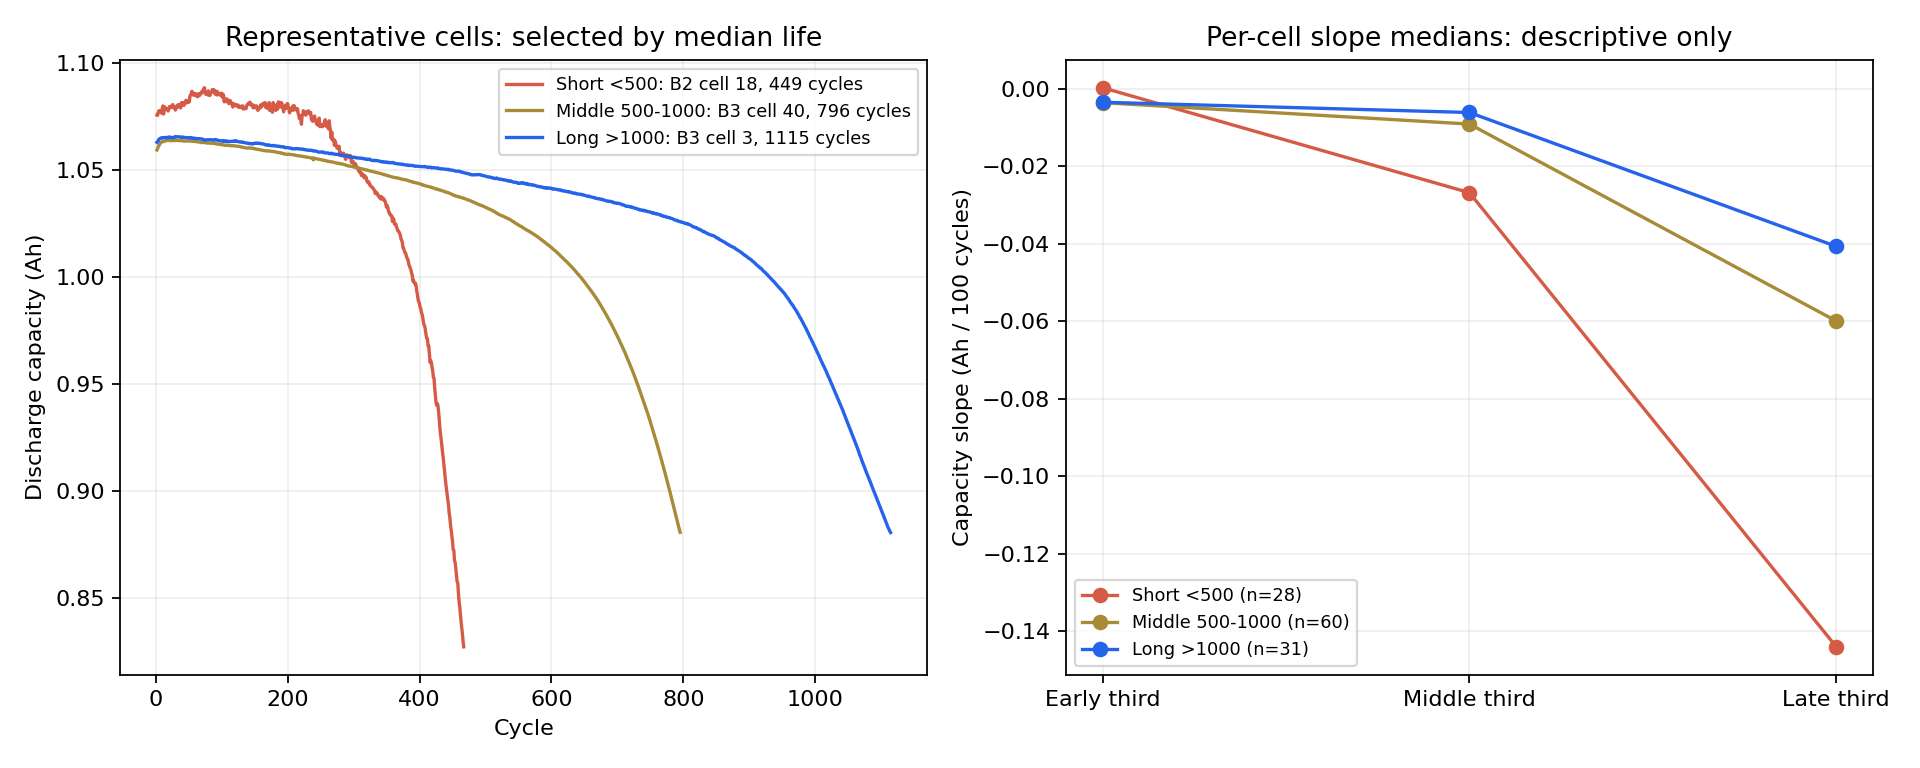

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '07_life_groups_degradation.png'))
plt.axis('off')
plt.show()

In [6]:
pd.read_csv(OUT / 'life_group_degradation.csv')

life_group,n_cells,early_slope_ah_per100_median,middle_slope_ah_per100_median,late_slope_ah_per100_median
short_lt500,28,0.000,-0.027,-0.144
middle_500_1000,60,-0.004,-0.009,-0.060
long_gt1000,31,-0.003,-0.006,-0.041


In [7]:
knee = pd.read_csv(OUT / 'knee_timing_summary.csv')
knee[knee.scope=='Pooled (descriptive)']

scope,life_group,n_cells,n_shape_ok,n_search_boundary,n_interior_shape_ok,interior_candidate_min_cycle,interior_candidate_median_cycle,interior_candidate_max_cycle,interior_candidate_median_fraction_of_life
Pooled (descriptive),short_lt500,28,28,4,24,313.195,363.285,406.177,0.807
Pooled (descriptive),middle_500_1000,60,59,17,42,387.453,614.363,783.076,0.765
Pooled (descriptive),long_gt1000,31,31,12,19,759.291,907.719,1532.927,0.785


### 3. ΔQ(V) 곡선 분석

`ΔQ(V) = Q100(V) − Q10(V)`를 공통 2.0–3.5V·1,000점 전압축에서 계산했습니다. 배치별 곡선의 중앙값과 IQR은 다음과 같습니다.



두 번째 그림은 배치마다 장·중간·단수명 곡선을 비교합니다. 실제로 없는 수명 그룹은 그리지 않습니다. 음영은 셀 간 IQR로 평균의 신뢰구간이 아닙니다.

| Batch | 수명 그룹 | 셀 수 | log10 ΔQ 분산 중앙값 | ΔQ 최솟값 중앙값 (Ah) |
| --- | --- | --- | --- | --- |
| 1 | 단수명 <500 | 0 | — | — |
| 1 | 중간 500–1,000 | 31 | -3.769 | -0.039 |
| 1 | 장수명 >1,000 | 5 | -4.059 | -0.029 |
| 2 | 단수명 <500 | 28 | -3.446 | -0.056 |
| 2 | 중간 500–1,000 | 8 | -4.153 | -0.027 |
| 2 | 장수명 >1,000 | 3 | -4.272 | -0.019 |
| 3 | 단수명 <500 | 0 | — | — |
| 3 | 중간 500–1,000 | 21 | -4.092 | -0.028 |
| 3 | 장수명 >1,000 | 23 | -4.317 | -0.020 |

같은 Batch 2에서 단수명 28셀의 log 분산 중앙값은 -3.446, 장수명 3셀은 -4.272입니다. 단수명에서 곡선 변화의 크기가 더 크지만 장수명 표본이 3셀뿐이므로 일반화에 주의합니다. Batch 1의 ΔQ log 분산–log 수명 Pearson은 −0.844입니다.

**핵심 발견:** 초기 총 용량에서 뚜렷하지 않은 변화가 ΔQ 곡선에 드러나므로 log 분산을 핵심 피처로 구현했습니다. 분산은 곡선의 상수 원점 이동에 불변이지만 평균·최솟값은 그렇지 않아, 배치 간 원점·절차 차이를 모두 교정했다고 해석하지 않습니다. 단수명·장수명 곡선 차이가 화학적 원인이나 예측 정확도를 직접 입증하지도 않습니다.



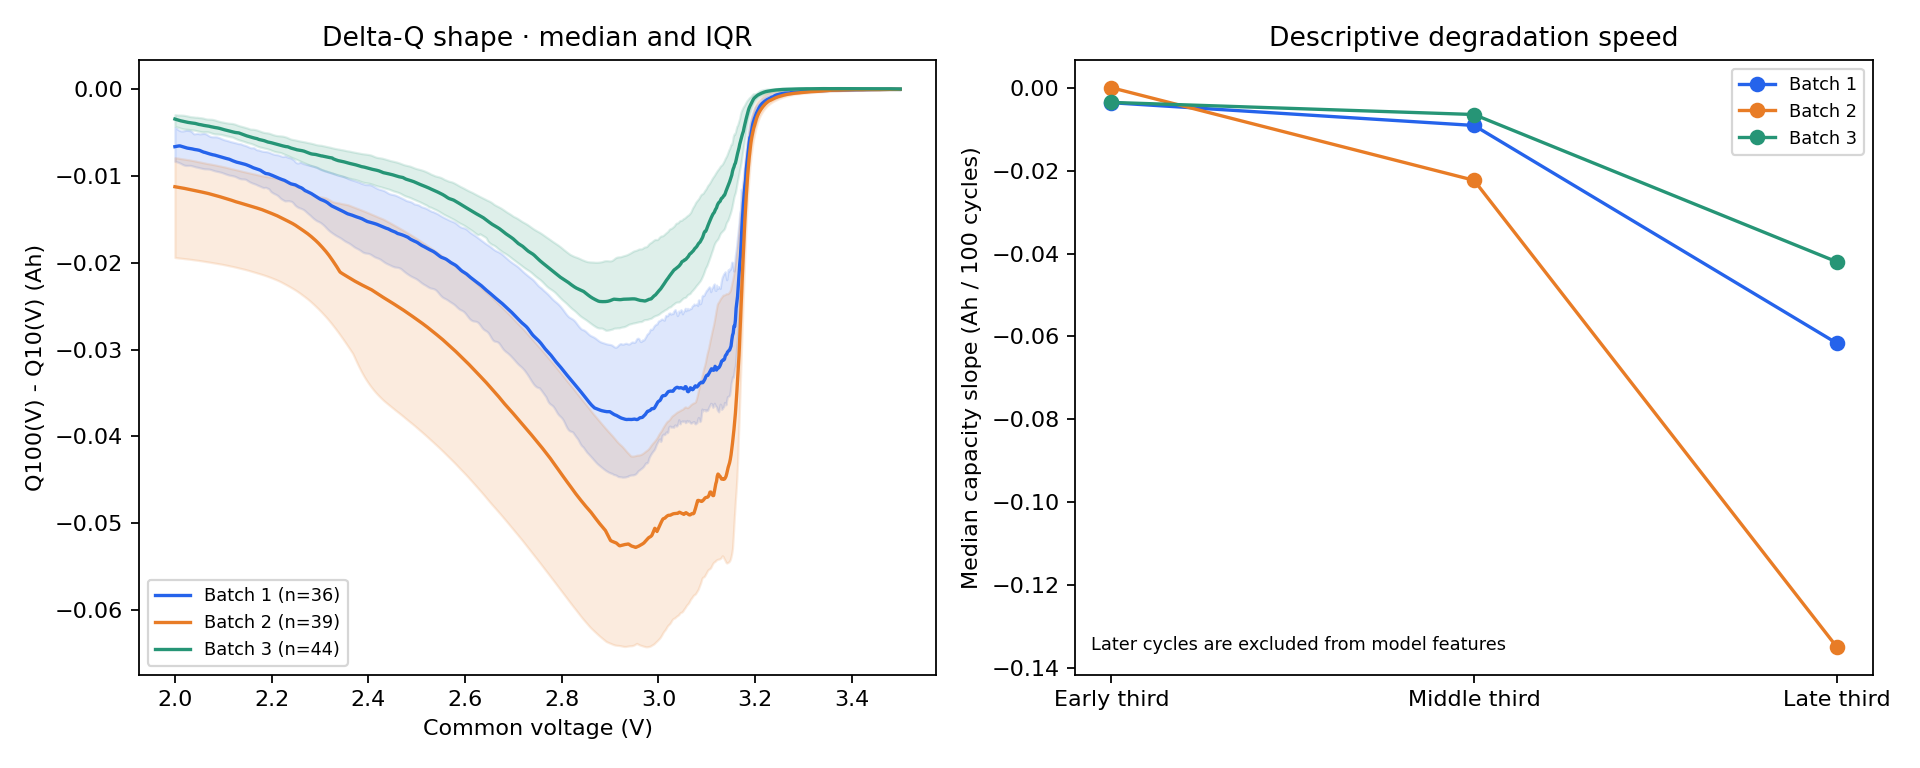

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '04_eda_curve_evidence.png'))
plt.axis('off')
plt.show()

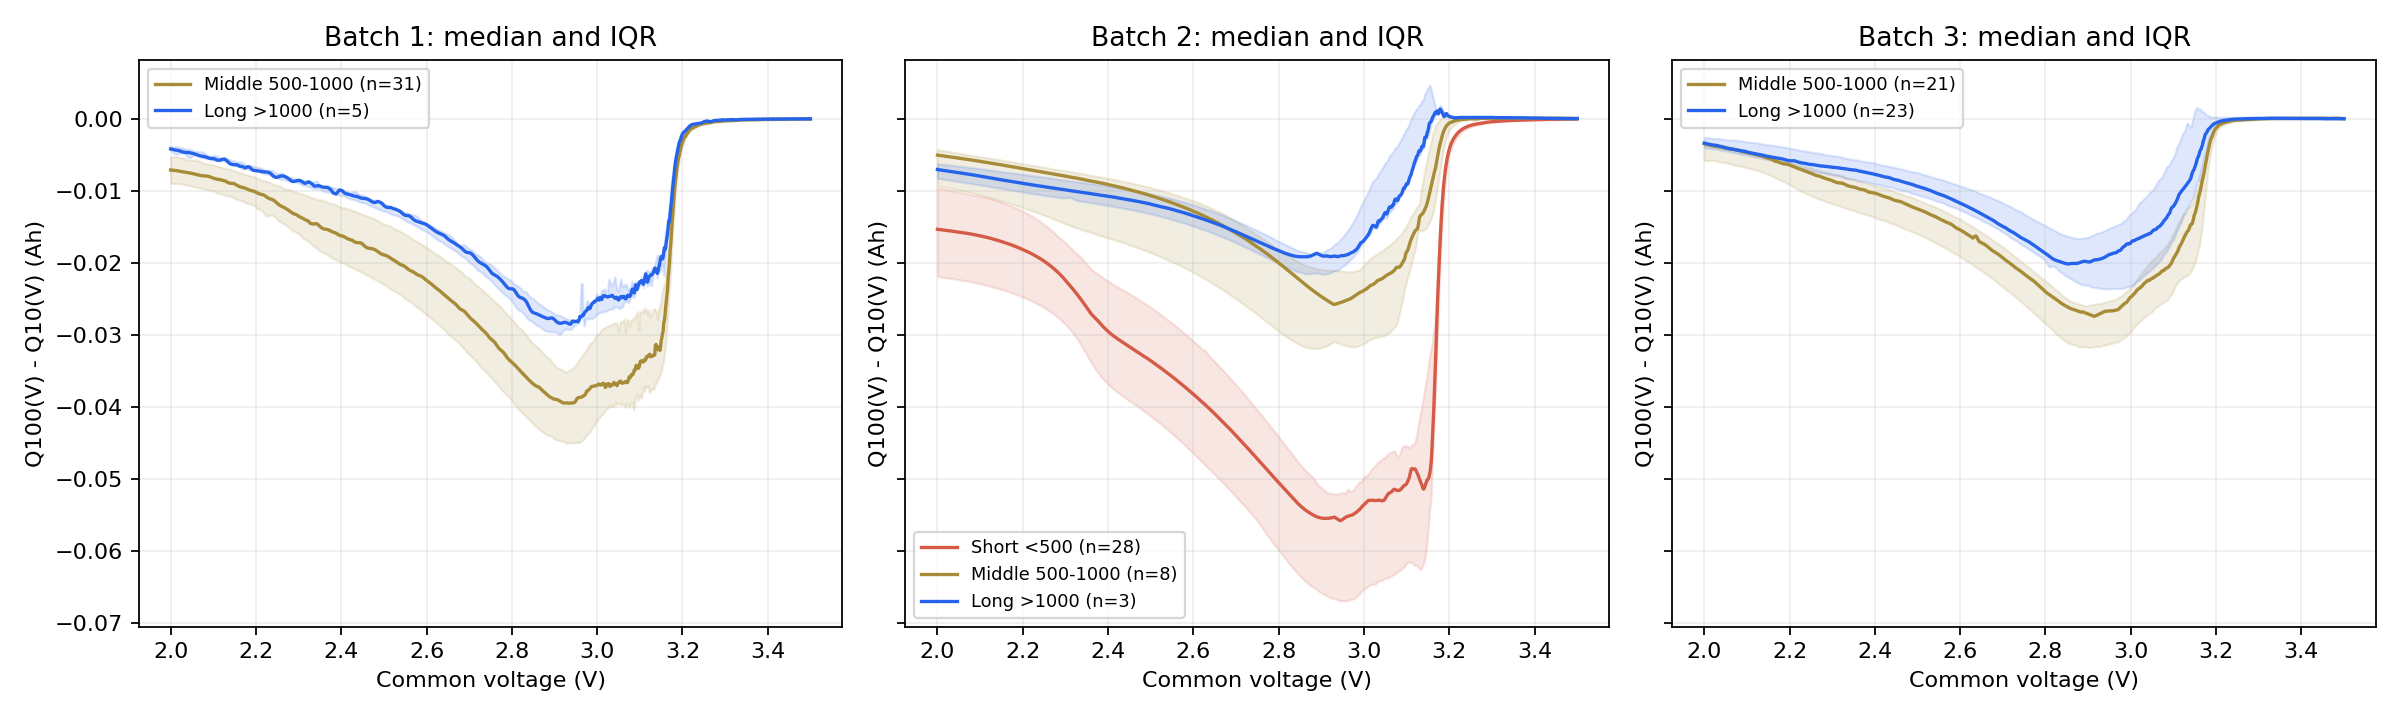

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '08_dq_life_groups.png'))
plt.axis('off')
plt.show()

In [10]:
pd.read_csv(OUT / 'life_group_statistics.csv')

batch,life_group,n_cells,cycle_life_median,log10_dq_variance_median,dq_mean_median,dq_min_median,early_slope_ah_per100_median,middle_slope_ah_per100_median,late_slope_ah_per100_median
1,short_lt500,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,middle_500_1000,31,731.000,-3.769,-0.018,-0.039,-0.004,-0.009,-0.068
1,long_gt1000,5,1051.000,-4.059,-0.012,-0.029,-0.003,-0.008,-0.046
2,short_lt500,28,449.500,-3.446,-0.029,-0.056,0.000,-0.027,-0.144
2,middle_500_1000,8,800.000,-4.153,-0.011,-0.027,0.001,-0.011,-0.082
2,long_gt1000,3,1140.000,-4.272,-0.008,-0.019,-0.004,-0.007,-0.051
3,short_lt500,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,middle_500_1000,21,828.000,-4.092,-0.012,-0.028,-0.004,-0.008,-0.050
3,long_gt1000,23,1155.000,-4.317,-0.009,-0.020,-0.004,-0.006,-0.038


### 4. 충전 속도(C-rate)와 수명의 관계


첫 그림과 아래 표는 **학습 Batch 1의 모든 충전 프로토콜**을 셀 수와 함께 비교합니다. 두 단계 정책은 80% SOC까지의 이상적 충전 시간을 환산한 등가 C-rate로 요약했으며 실제 측정 충전 시간과는 다릅니다. 전체 배치의 프로토콜별 평균·중앙값은 [policy_summary.csv](results/policy_summary.csv)에 있습니다.

| Batch 1 충전 프로토콜 | 셀 수 | 등가 C-rate | 평균 수명 (회) |
| --- | --- | --- | --- |
| 4.4C(80%)-4.4C | 1 | 4.400 | 1074.000 |
| 5.4C(40%)-3.6C | 1 | 4.320 | 1054.000 |
| 6C(30%)-3.6C | 1 | 4.235 | 1014.000 |
| 8C(15%)-3.6C | 2 | 4.014 | 1008.500 |
| 6C(40%)-3C | 2 | 4.000 | 935.500 |
| 6C(50%)-3C | 2 | 4.364 | 888.500 |
| 5.4C(60%)-3.6C | 2 | 4.800 | 859.500 |
| 6C(40%)-3.6C | 2 | 4.500 | 856.000 |
| 5.4C(60%)-3C | 2 | 4.500 | 799.500 |
| 6C(50%)-3.6C | 2 | 4.800 | 792.500 |
| 5.4C(50%)-3C | 1 | 4.154 | 788.000 |
| 4.8C(80%)-4.8C | 2 | 4.800 | 753.000 |
| 6C(60%)-3C | 2 | 4.800 | 744.000 |
| 5.4C(70%)-3C | 2 | 4.909 | 739.500 |
| 7C(30%)-3.6C | 2 | 4.402 | 722.500 |
| 8C(25%)-3.6C | 2 | 4.347 | 676.500 |
| 7C(40%)-3C | 2 | 4.200 | 676.000 |
| 7C(40%)-3.6C | 2 | 4.755 | 621.000 |
| 8C(35%)-3.6C | 2 | 4.741 | 607.500 |
| 5.4C(80%)-5.4C | 2 | 5.400 | 546.500 |

| Batch | 셀 수 | 최소 C-rate | 최대 C-rate | Spearman (원 계산) | Spearman (동률 보정) |
| --- | --- | --- | --- | --- | --- |
| 1 | 36 | 4.000 | 5.400 | -0.435 | -0.436 |
| 2 | 39 | 4.790 | 4.807 | 0.321 | 0.353 |
| 3 | 44 | 4.794 | 4.813 | -0.132 | -0.132 |

표의 동률 보정은 부동소수점 계산의 미세한 차이로 같은 C-rate의 순위가 달라지는 것을 막기 위해 소수 8자리로 반올림한 민감도 비교입니다. 외부 평가 배치의 등가 C-rate는 거의 4.8C에 집중되어 있어 상관 부호만으로 속도 효과가 뒤집혔다고 해석하기 어렵습니다.

**핵심 발견:** Batch 1에서 등가 C-rate–수명 Spearman은 약 −0.44이지만 거의 같은 등가 속도에서도 프로토콜과 배치별 수명이 다릅니다. 속도 하나로 수명을 설명하거나 빠른 충전의 인과 효과를 확정할 수 없습니다. Batch 1 프로토콜별 1–2셀의 평균 차이는 통계적 유의성을 입증한 결과가 아니며, 같은 정책이 train·valid에 겹치지 않도록 정책 단위로 검증했습니다.



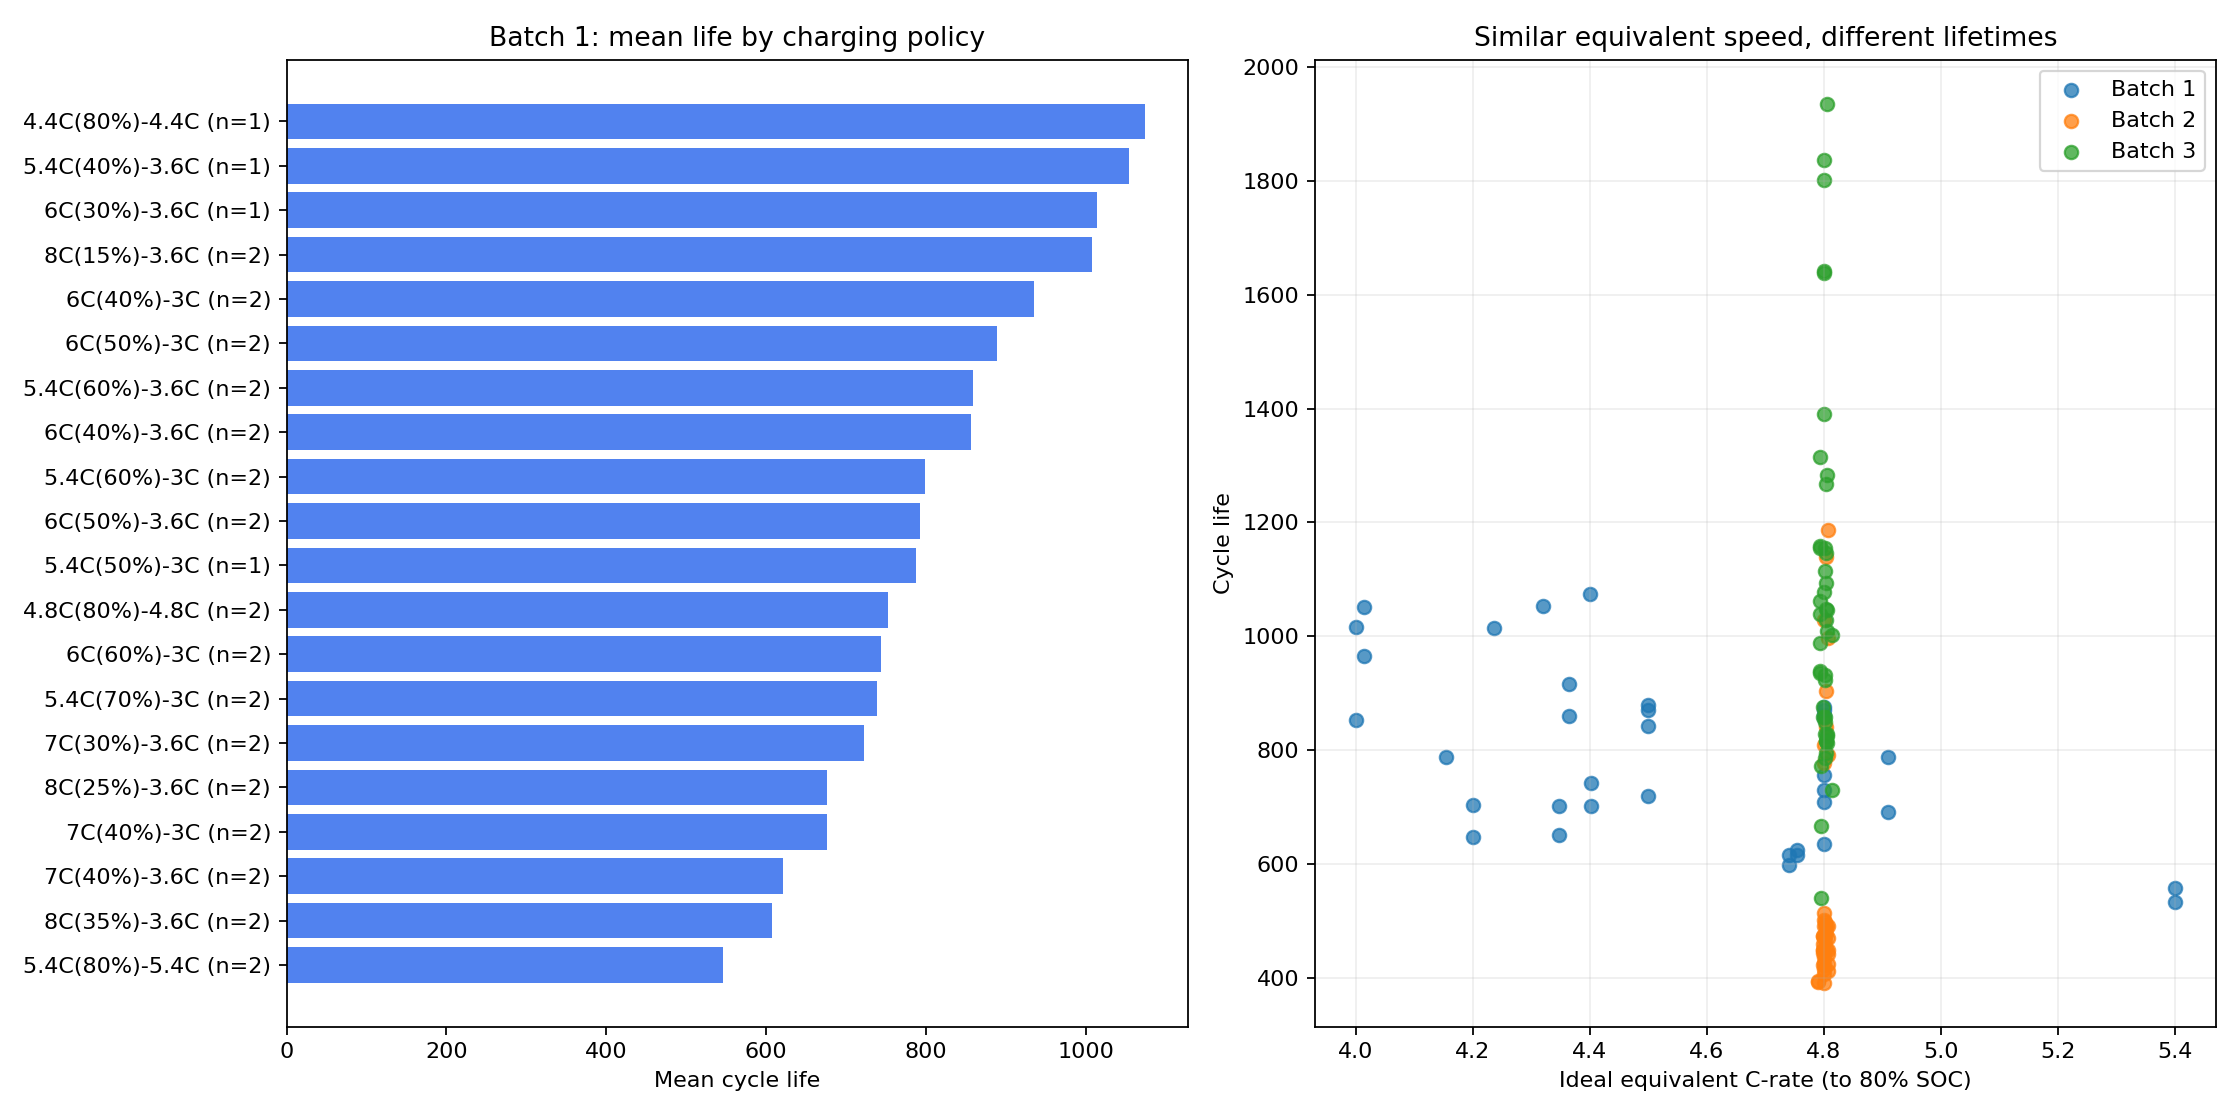

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '09_charging_policy_life.png'))
plt.axis('off')
plt.show()

In [12]:
policy = pd.read_csv(OUT / 'policy_summary.csv')
policy[policy.batch==1].sort_values('mean_life',ascending=False)

batch,policy,n_cells,mean_life,median_life,equivalent_c
1,4.4C(80%)-4.4C,1,1074.000,1074.000,4.400
1,5.4C(40%)-3.6C,1,1054.000,1054.000,4.320
1,6C(30%)-3.6C,1,1014.000,1014.000,4.235
1,8C(15%)-3.6C,2,1008.500,1008.500,4.014
1,6C(40%)-3C,2,935.500,935.500,4.000
1,6C(50%)-3C,2,888.500,888.500,4.364
1,5.4C(60%)-3.6C,2,859.500,859.500,4.800
1,6C(40%)-3.6C,2,856.000,856.000,4.500
1,5.4C(60%)-3C,2,799.500,799.500,4.500
1,6C(50%)-3.6C,2,792.500,792.500,4.800


In [13]:
pd.read_csv(OUT / 'charging_rate_correlations.csv')

batch,n_valid,equivalent_c_min,equivalent_c_max,spearman_equivalent_c_life,spearman_equivalent_c_life_rounded8
1,36,4.000,5.400,-0.435,-0.436
2,39,4.790,4.807,0.321,0.353
3,44,4.794,4.813,-0.132,-0.132


### 5. 추가 확인: 피처 중복·전이 안정성과 품질


ΔQ 요약값 사이의 중복이 크고 보조 피처는 배치별 상관 부호가 달라질 수 있습니다. Batch 1 전체 10개 피처 최대 VIF 290.43를 대표 5개로 줄이면 2.74입니다. 통합 상관행렬은 탐색용이며 실제 후보 선택은 Batch 1 개발 CV로 제한합니다. 상관 변화 자체를 오차의 인과 원인으로 단정하지 않습니다.

**핵심 발견:** 중복 피처를 줄이고 포함·제외 비교와 정규화를 사용하되 실제 예측 개선은 CV로 검증해야 합니다. IR 0 이하·비유한 값과 초기 용량 범위 이상을 점검하고 제외·대치 기준과 유효 표본 수를 기록했습니다. 상세 계산은 `eda_distribution.csv`, `life_group_statistics.csv`, `knee_timing_summary.csv`, `eda_vif.csv`, `cell_audit_all.csv` 및 [DAY 2 노트북](03_modeling.ipynb)에 있습니다. [기존 통합 EDA](../30-ESSHealth-scratch.ipynb)는 DAY 1 탐색 기록입니다.

### EDA → 모델 전략 연결

| 관측 근거 | 모델 설계·구현 | 검증 근거 |
| --- | --- | --- |
| 연속 수명과 초기 ΔQ 신호 | 총수명 회귀·ΔQ log 분산 핵심 입력 | 단일 피처 기준선 및 후보 CV 비교 |
| 후반 열화와 knee는 미래 관측 | 100회 이내 피처만 사용 | 미래 사이클 값을 바꾸어도 피처가 같은지 검사 |
| ΔQ 요약값의 중복 | 대표 5개 피처의 16개 부분집합 비교 | `feature_ablation.csv`, 학습 배치 VIF |
| 보조 피처의 배치별 상관 변화 | 포함·제외 효과를 Batch 1에서 비교 | `paired_ablation.csv`, 피처별 배치 상관 |
| 작은 표본과 정책별 실험 | 정규화 선형 모델·정책별 분할 | Nested-CV 및 정책 Hold-out |
| Batch 1의 단수명 부재 | 외부 배치의 과대예측 편향 점검 | Batch 2 기준선·부호 오차·수명 구간 분석 |



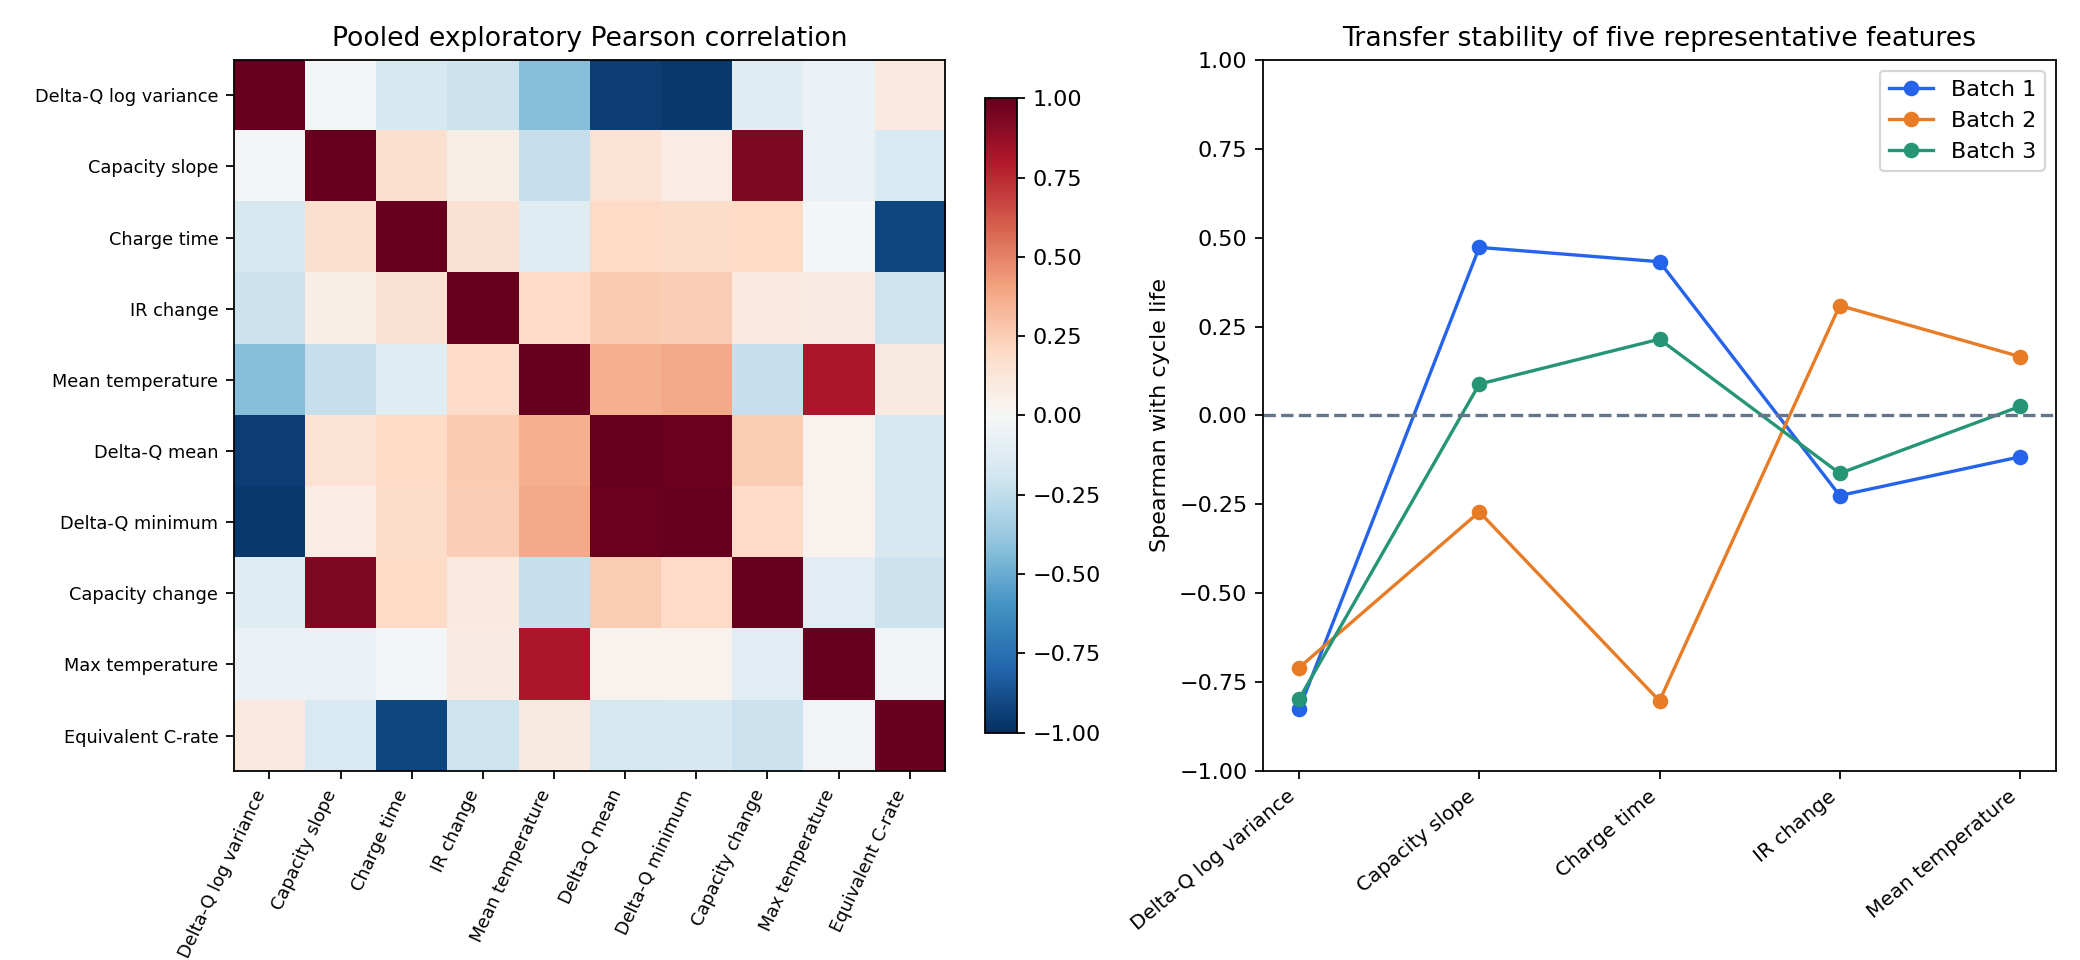

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '05_feature_stability.png'))
plt.axis('off')
plt.show()

In [15]:
correlations = pd.read_csv(OUT / 'eda_correlations.csv')
correlations.pivot(index='feature',columns='batch',values='spearman_life').reset_index()

batch,feature,1,2,3
,charge_time_mean_2_6,0.432,-0.802,0.214
,dq_mean,0.758,0.697,0.756
,dq_min,0.787,0.661,0.776
,ideal_equivalent_c,-0.435,0.321,-0.132
,ir_change_100_2,-0.225,0.309,-0.163
,log10_dq_variance,-0.826,-0.709,-0.797
,qd_change_100_2,0.417,-0.097,-0.143
,qd_slope_2_100,0.473,-0.271,0.088
,tavg_mean_2_100,-0.116,0.166,0.025
,tmax_max_2_100,-0.100,-0.152,-0.038


In [16]:
vifs = pd.read_csv(OUT / 'eda_vif.csv')
vifs.groupby(['scope','feature_set']).agg(n_cells=('n_cells','first'),max_vif=('vif','max')).reset_index()

scope,feature_set,n_cells,max_vif
Batch 1,all10,36,290.425
Batch 1,representative5,36,2.739
Pooled (descriptive),all10,113,99.261
Pooled (descriptive),representative5,113,1.313


## 2. 피처·전처리·분할

초기 100회까지의 방전곡선·용량 기울기·충전 시간·IR·온도만 사용합니다. 공통 전압축을 검사하고, fold 안에서 결측 대치·표준화합니다. 개발 29셀과 검증 7셀은 기존 정책 단위 분할을 유지합니다. Batch 1의 10셀은 불완전 목표값, Batch 2의 8셀은 결측 목표값 때문에 제외합니다.

In [17]:
audit = pd.read_csv(OUT / 'cell_audit.csv')
print(audit.groupby(['batch','included','reason']).size().to_string())
manifest = pd.read_csv(OUT / 'split_manifest.csv')
print(manifest.to_string(index=False))

batch  included  reason                         
1      False     continued_in_later_run              5
                 early_stopped_incomplete_target     5
       True      included                           36
2      False     missing_or_invalid_cycle_life       8
       True      included                           39
 batch  cell_id         policy       split
     1        5 4.4C(80%)-4.4C development
     1        9 5.4C(40%)-3.6C development
     1       11   5.4C(50%)-3C development
     1       14   5.4C(60%)-3C development
     1       15   5.4C(60%)-3C development
     1       16 5.4C(60%)-3.6C development
     1       17 5.4C(60%)-3.6C development
     1       18   5.4C(70%)-3C development
     1       19   5.4C(70%)-3C development
     1       20 5.4C(80%)-5.4C development
     1       21 5.4C(80%)-5.4C development
     1       24     6C(40%)-3C development
     1       25     6C(40%)-3C development
     1       26   6C(40%)-3.6C development
     1       27   6C(40%)-3.6C 

### 원본에서 피처·분할을 직접 재현

이 셀은 저장 표를 읽는 것에 더해 원본 MAT에서 초기 피처를 다시 추출하고 정책 분리와 계산값 일치를 확인합니다.

In [18]:
from src.preprocess import load_batch, development_split
from src.features import ALL_FEATURES
from src.train import fit_model, predict, metrics
frozen = json.loads((OUT / 'frozen_config.json').read_text())
config = frozen['selected_config']
batch1, audit1 = load_batch(1)
dev, valid = development_split(batch1)
assert not set(dev.policy) & set(valid.policy)
stored = pd.read_csv(OUT / 'cell_features.csv')
expected = stored[stored.batch==1].set_index('cell_id').loc[batch1.cell_id]
np.testing.assert_allclose(batch1[ALL_FEATURES],expected[ALL_FEATURES],equal_nan=True)
print('원본','추출:',len(batch1),'셀, 개발',len(dev),'검증',len(valid))
batch1[['cell_id','policy',*frozen['features']]].head()

원본 추출: 36 셀, 개발 29 검증 7


cell_id,policy,log10_dq_variance,charge_time_mean_2_6
5,4.4C(80%)-4.4C,-4.179,10.968
6,4.8C(80%)-4.8C,-3.769,10.076
7,4.8C(80%)-4.8C,-3.813,10.025
9,5.4C(40%)-3.6C,-4.059,11.208
11,5.4C(50%)-3C,-4.147,11.669


## 3. 후보 비교 및 모델 선택

후보 선택은 개발 29셀의 정책 단위 4-fold CV에서만 수행합니다. nested CV의 외부 fold는 모델·피처·파라미터 선택에 사용하지 않습니다. 과제의 Train 행은 **개발 Nested-CV** 외부 fold 검증오차 평균이며 학습 데이터에 적합한 오차가 아닙니다.

In [19]:
print(json.dumps(json.loads((OUT / 'frozen_config.json').read_text()), ensure_ascii=False, indent=2))
cv = pd.read_csv(OUT / 'cv_results.csv')
print(cv.groupby('model',sort=False).head(1).to_string(index=False))
print(pd.read_csv(OUT / 'nested_cv_folds.csv').to_string(index=False))
print(pd.read_csv(OUT / 'baseline_comparison.csv').to_string(index=False))

{
  "selected_config": {
    "model": "Ridge",
    "feature_set": "plus_2",
    "alpha": 0.1
  },
  "features": [
    "log10_dq_variance",
    "charge_time_mean_2_6"
  ],
  "selection_rule": "minimum mean 4-fold protocol-grouped development CV MAPE",
  "target_transform": "log10, inverse 10**prediction",
  "target_mape_pct": 9.1,
  "n_final_training": 36,
  "n_development": 29,
  "n_holdout": 7,
  "python": "3.11.15",
  "sklearn": "1.6.1",
  "pandas": "2.3.3",
  "numpy": "2.0.2"
}
 candidate_id        model feature_set  cv_mean_mape_pct  cv_std_mape_pct  fold_1_mape_pct  fold_2_mape_pct  fold_3_mape_pct  fold_4_mape_pct  alpha  l1_ratio    C gamma  epsilon  max_depth  min_samples_leaf target_scale
           62        Ridge      plus_2          9.024174         2.581483         4.567117        10.763399        10.573680        10.192499   0.10       NaN  NaN   NaN      NaN        NaN               NaN          NaN
           68   ElasticNet      plus_2          9.025828         2.77428

In [20]:
print(pd.read_csv(OUT / 'feature_definitions.csv').to_string(index=False))
print(pd.read_csv(OUT / 'feature_ablation.csv').to_string(index=False))

             feature                 의미     window       unit  selected
   log10_dq_variance ΔQ(V) 변화 분산의 log10 100회 − 10회 log10(Ah²)      True
      qd_slope_2_100          방전 용량 기울기     2–100회   Ah/cycle     False
charge_time_mean_2_6        초기 평균 충전 시간       2–6회        min      True
     ir_change_100_2           내부저항 변화량  100회 − 2회          Ω     False
     tavg_mean_2_100           초기 평균 온도     2–100회         °C     False
      feature_set  n_features                                                                                  features      model  cv_mean_mape_pct
           plus_2           2                                                   log10_dq_variance, charge_time_mean_2_6      Ridge          9.024174
         variance           1                                                                         log10_dq_variance      Ridge          9.025860
         plus_2_4           3                                  log10_dq_variance, charge_time_mean_2_6, tavg_mean_2_100 E

### CV 후보 비교

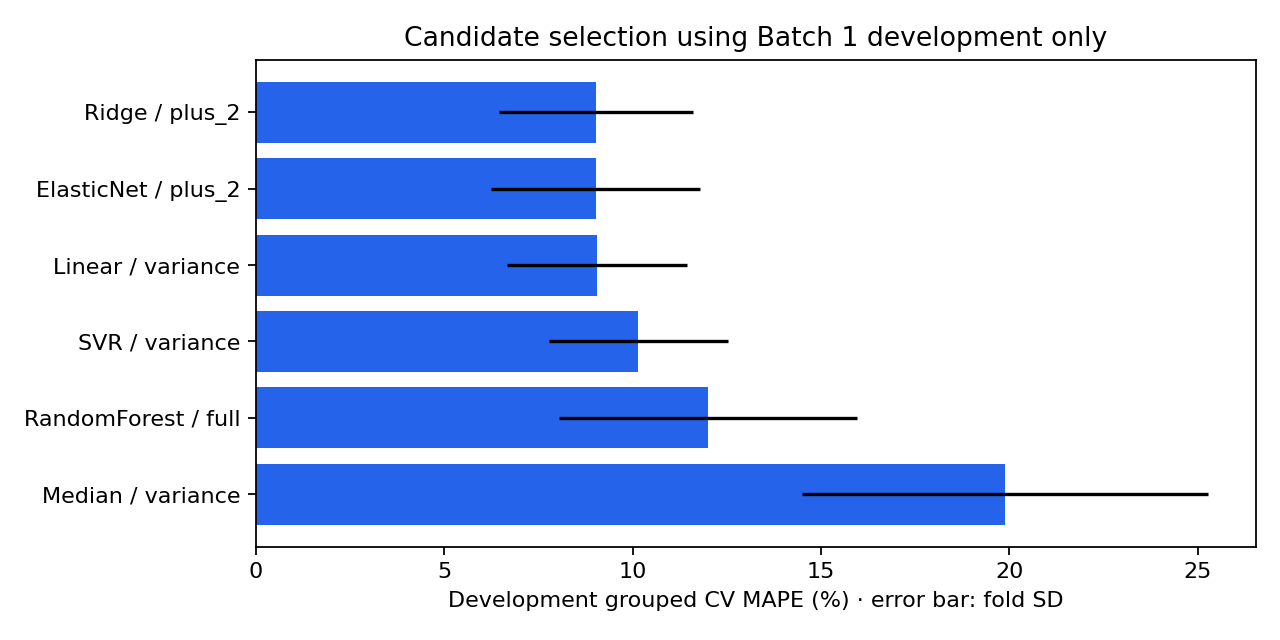

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.imshow(plt.imread(OUT / '01_model_comparison.png'))
plt.axis('off')
plt.show()

### 작은 CV 개선을 해석하는 기준

단일 ΔQ 피처 CV **9.02586%**와 충전 시간을 추가한 선택 후보 **9.02417%**의 차이는 **0.00169%p**로 매우 작습니다. 충전 시간 피처의 실질적 개선이 입증됐다고 주장할 수 없습니다. '최적 모델'은 현재 후보군·고정 분할·선택 지표에서의 최저 후보를 의미합니다. 충전 시간의 선택 근거는 재검토 대상으로 명시하고 다음 개발 실험에서 단일 피처의 단순 모델을 우선 비교합니다. 현재 시험 결과로 모델을 바꾸지 않으며 개선 모델은 후속 미사용 배치에서 검증해야 합니다.

`paired_ablation.csv`는 같은 Ridge alpha·같은 CV fold에서 피처 하나의 추가 효과를 비교합니다. delta가 음수일 때 개선입니다. 최저 파라미터를 각각 고른 조합 비교와 구분해 해석합니다. 이번 고정 모델은 Batch 2/3 결과로 재선택하지 않았습니다.


In [22]:
paired = pd.read_csv(OUT / 'paired_ablation.csv')
paired.loc[(paired.base_set=='variance') & (paired.alpha==0.1)]

added_feature,base_set,expanded_set,alpha,delta_mape_pp,folds_improved,n_folds
qd_slope_2_100,variance,plus_1,0.100,1.920,0,4
charge_time_mean_2_6,variance,plus_2,0.100,-0.032,3,4
ir_change_100_2,variance,plus_3,0.100,1.907,1,4
tavg_mean_2_100,variance,plus_4,0.100,0.378,1,4


### 고정 모델 학습·평가를 직접 재현

아래 코드는 개발 29셀 모델과 Batch 1 전체 36셀 모델을 구분해 적합하고 그 뒤 Batch 2를 읽습니다. 설정을 새로 선택하지 않습니다. 전체 후보·nested CV 재현은 `python -m src.train --batch3`로 실행합니다.

In [23]:
# 고정 설정으로 직접 재학습: 개발 29셀 → Hold-out, 전체 36셀 → Batch 2
development_model = fit_model(dev,config)
valid_prediction = predict(development_model,valid,config)
final_model = fit_model(batch1,config)
batch2, audit2 = load_batch(2)
test_prediction = predict(final_model,batch2,config)
saved = pd.read_csv(OUT / 'predictions.csv')
expected_test = saved[saved.batch==2].set_index('cell_id').loc[batch2.cell_id]
np.testing.assert_allclose(test_prediction,expected_test.predicted_cycle_life)
pd.DataFrame([{'구분':'Valid',**metrics(valid.cycle_life,valid_prediction)},{'구분':'Test Batch 2',**metrics(batch2.cycle_life,test_prediction)}])

구분,mape_pct,mae_cycles,rmse_cycles
Valid,10.435,85.643,90.719
Test Batch 2,28.609,141.752,158.676


## 4. 성능 리포팅 및 Gap 해석

Batch 2 MAPE는 **28.609%**, 과제 Target 9.1%와의 차이는 **+19.509%p**입니다. Valid−Train은 -0.407%p, Test−Valid는 +18.174%p입니다. 작은 표본의 정책 분할과 CV fold 변동을 함께 고려해야 하며, Gap 한 값만으로 과적합을 확정할 수 없습니다.

Gap은 각각 Valid−Train, Test−Valid, Test−9.1이고 단위는 %p입니다. Valid는 29셀 모델, Test는 고정 설정을 36셀로 재학습한 모델입니다. 원논문 2017-06-30과 과제 지정 Batch 2 2018-02-20은 다르며 Target 비교는 동일 조건 재현이 아닙니다.

In [24]:
print(pd.read_csv(OUT / 'model_performance.csv').to_string(index=False))
print(pd.read_csv(OUT / 'metrics.csv').to_string(index=False))

                      구분  MAPE (%)                                  비고
      Train (Batch 1 CV) 10.841921 개발 Nested-CV (29셀); 외부 fold 검증오차 평균
Valid (Batch 1 Hold-out) 10.435313                정책 분리 7셀; 개발 29셀로 학습
          Test (Batch 2) 28.609187     Batch 1 36셀로 재학습한 고정 모델; 39셀 평가
       Gap (Train-Valid) -0.406609  Valid − Train; (+): 오차 증가, 과적합 가능성
        Gap (Valid-Test) 18.173875  Test − Valid; (+): 배치 간 일반화 저하 가능성
       Gap (Target-Test) 19.509187     Test − 9.1%; 과제 Target 대비 참고 비교
                   index  n_cells  mape_pct  mae_cycles  rmse_cycles
      Train (Batch 1 CV)       29 10.841921   86.503932   102.695419
Valid (Batch 1 Hold-out)        7 10.435313   85.642692    90.719066
          Test (Batch 2)       39 28.609187  141.752359   158.676111


과제 양식의 행 이름을 유지하되 **Gap (Train-Valid)은 Valid − Train으로 계산**합니다. Gap (Valid-Test)은 Test − Valid, Gap (Target-Test)은 Test − 9.1이며 모두 %p입니다. Train은 학습 오차가 아니라 **개발 Nested-CV 검증오차**입니다.

### 원 단위 예측과 Batch 2 잔차

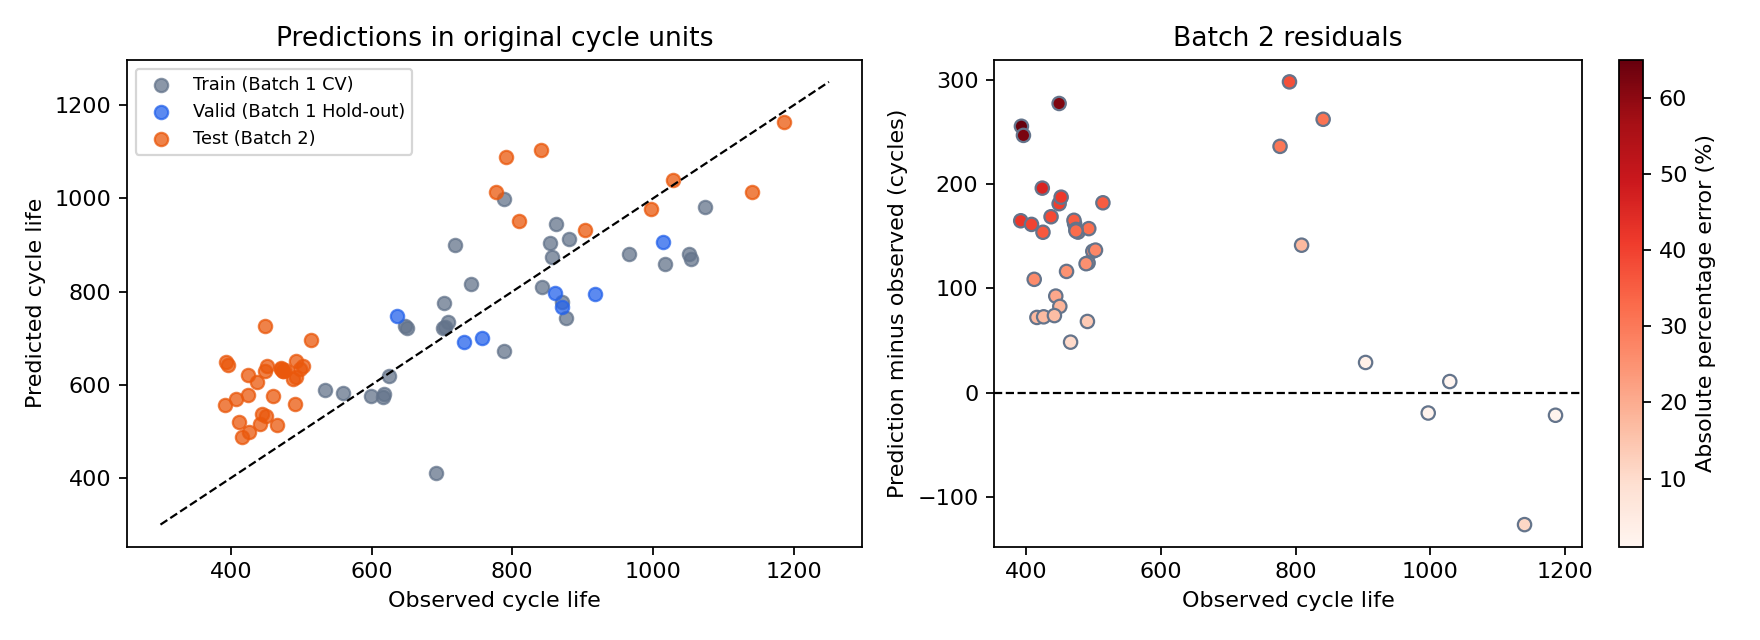

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.imshow(plt.imread(OUT / '02_predictions_residuals.png'))
plt.axis('off')
plt.show()

### 같은 Batch 2에서의 기준선 비교

Batch 1 전체 36셀의 **산술 중앙값 772.5회**를 Batch 2 모든 셀에 동일하게 예측하는 기준선입니다. Batch 2 정답을 이용해 중앙값을 정하지 않았으며, 최종 모델과 같은 39셀에서 비교했습니다. 기존 `baseline_comparison.csv`의 개발 CV·Hold-out 기준선과 구분합니다.

| model | n_cells | mape_pct | mae_cycles | rmse_cycles | mape_reduction_vs_baseline_pct |
| --- | --- | --- | --- | --- | --- |
| Batch 1 median baseline | 39 | 58.728 | 284.782 | 301.423 | 0.000 |
| Frozen selected model | 39 | 28.609 | 141.752 | 158.676 | 51.285 |

모델 MAPE 28.61%는 기준선 58.73%보다 **상대적으로 51.29% 감소**했습니다. 이는 예측 신호가 있음을 보여주지만 원논문 Target이나 교체 의사결정에 필요한 정확도를 충족했다는 뜻은 아닙니다. 비교 대상은 단순 상수 기준선으로 한정됩니다.


In [26]:
pd.read_csv(OUT / 'batch2_baseline_comparison.csv')

model,n_cells,constant_prediction_cycles,mape_pct,mae_cycles,rmse_cycles,mape_reduction_vs_baseline_pct
Batch 1 median baseline,39,772.500,58.728,284.782,301.423,0.000
Frozen selected model,39,NaN,28.609,141.752,158.676,51.285


### 오차 불확실성

과제의 Train은 학습 오차가 아니라 **개발 Nested-CV** 검증오차입니다. 외부 fold별 MAPE는 **5.44–16.62%**이고 Hold-out은 7셀뿐입니다. 평균과 Hold-out이 가깝고 검증에서 오차가 급증하지 않았지만, −0.407%p 차이를 안정성의 강한 증거로 해석할 수 없습니다.

충전 정책을 복원추출하고 선택된 정책의 모든 셀을 함께 포함하는 **정책 단위 bootstrap**(seed=42, 2,000회)으로 고정 모델 MAPE의 95% percentile 구간을 계산했습니다. 이 구간은 평가 표본의 불확실성만 나타내며 재학습·미래 배치의 불확실성이나 셀별 예측 구간은 아닙니다. Hold-out은 4정책뿐이라 구간 안정성도 제한됩니다.

| partition | mape_pct | ci_low_pct | ci_high_pct | n_cells | n_policies | bootstrap_samples | seed |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Valid (Batch 1 Hold-out) | 10.435 | 7.350 | 13.529 | 7 | 4 | 2000 | 42 |
| Test (Batch 2) | 28.609 | 22.054 | 35.605 | 39 | 12 | 2000 | 42 |
| Test (Batch 3) | 12.156 | 7.843 | 16.757 | 44 | 8 | 2000 | 42 |

In [27]:
pd.read_csv(OUT / 'metric_uncertainty.csv')

partition,mape_pct,ci_low_pct,ci_high_pct,n_cells,n_policies,bootstrap_samples,seed
Valid (Batch 1 Hold-out),10.435,7.350,13.529,7,4,2000,42
Test (Batch 2),28.609,22.054,35.605,39,12,2000,42
Test (Batch 3),12.156,7.843,16.757,44,8,2000,42


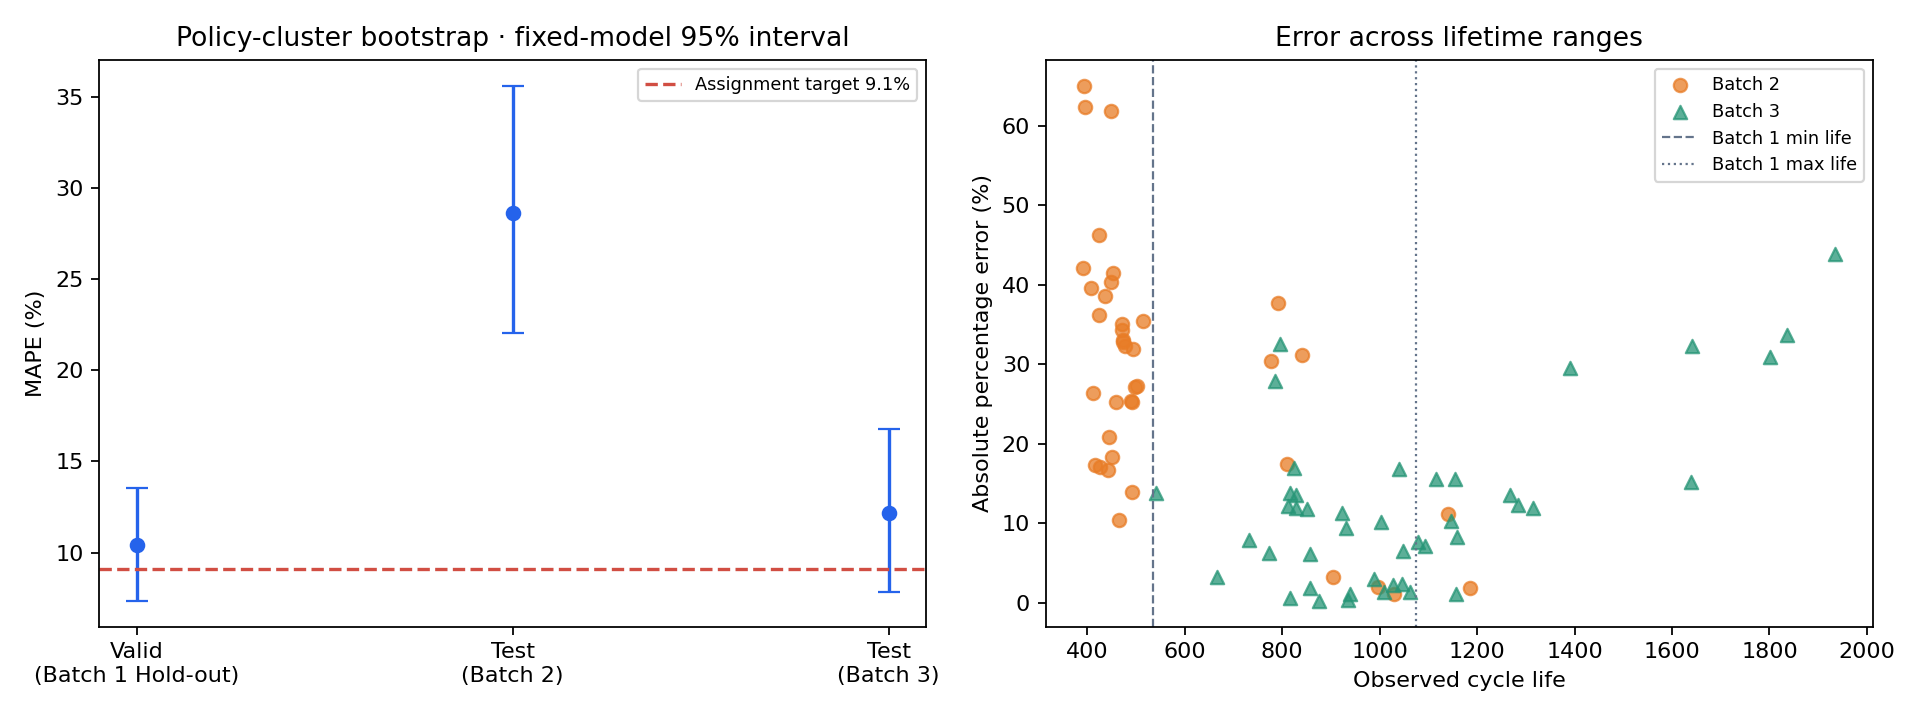

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '06_uncertainty_and_domain.png'))
plt.axis('off')
plt.show()

## 5. 오류 분석

가장 큰 오차 5셀은 아래와 같습니다. 예측값과 실제값의 차이를 원 사이클 단위로 복원해 분석했습니다. 상위 5셀은 모두 실제 수명 500회 미만이며, 모두 과대예측했습니다.

| cell_id | policy | cycle_life | predicted_cycle_life | ape_pct |
| --- | --- | --- | --- | --- |
| 6 | 3.6C(9%)-5C | 393.000 | 648.585 | 65.034 |
| 15 | 3.6C(9%)-5C | 396.000 | 642.824 | 62.329 |
| 18 | 5.2C(50%)-4.25C | 449.000 | 726.432 | 61.789 |
| 2 | 5.2C(50%)-4.25C | 424.000 | 620.207 | 46.275 |
| 19 | 6C(60%)-3C | 392.000 | 556.893 | 42.064 |

| group | n_cells | mape_pct | mae_cycles | rmse_cycles | mean_signed_error_cycles |
| --- | --- | --- | --- | --- | --- |
| standard_structure | 30 | 32.661 | 146.086 | 156.050 | 146.086 |
| newstructure | 9 | 15.102 | 127.308 | 167.131 | 89.962 |
| below_batch1_life_min | 30 | 32.661 | 146.086 | 156.050 | 146.086 |
| life_lt500 | 28 | 32.758 | 145.132 | 155.687 | 145.132 |
| life_500_to1000 | 8 | 23.070 | 163.198 | 189.285 | 158.298 |
| life_gt1000 | 3 | 4.660 | 53.025 | 74.471 | -45.947 |

Batch 2에서 **30/39셀**의 수명이 Batch 1 최소값(534회)보다 짧습니다. Batch 1만 본 모델이 짧은 수명 범위로 외삽해야 한다는 점이 주요 원인 가설입니다. `newstructure`는 데이터의 정책 문자열에 표시된 그룹이며 표의 성능은 사후 진단입니다. `standard_structure`와 `below_batch1_life_min`은 정확히 같은 30셀로, 두 행은 독립적인 원인 증거가 아닙니다. 구조와 수명 범위의 효과를 분리하거나 인과관계로 단정할 수 없습니다. 잔차 부호가 양수이면 수명 과대예측이므로 교체 계획에서 특히 주의해야 합니다.

선택된 피처의 배치별 상관은 아래와 같습니다. 초기 충전 시간의 상관 부호가 배치에 따라 달라진다는 DAY 1 관찰과 일치합니다. 이는 보조 피처 전이의 위험을 설명하는 진단이며 오차의 인과 원인을 확정하지 않습니다.

| feature | batch1_spearman | batch2_spearman |
| --- | --- | --- |
| log10_dq_variance | -0.826 | -0.709 |
| charge_time_mean_2_6 | 0.432 | -0.802 |

개선 방향: 새 개발 데이터에서 단수명 셀을 확보하고, 구조·온도·충전 조건의 영향을 독립적으로 검증합니다. 현재 Batch 2를 보고 피처나 파라미터를 재선택하지 않았으며, 개선 모델은 별도 미사용 배치로 평가해야 합니다.

### 고정 모델 평가 후의 배치 차이 분석

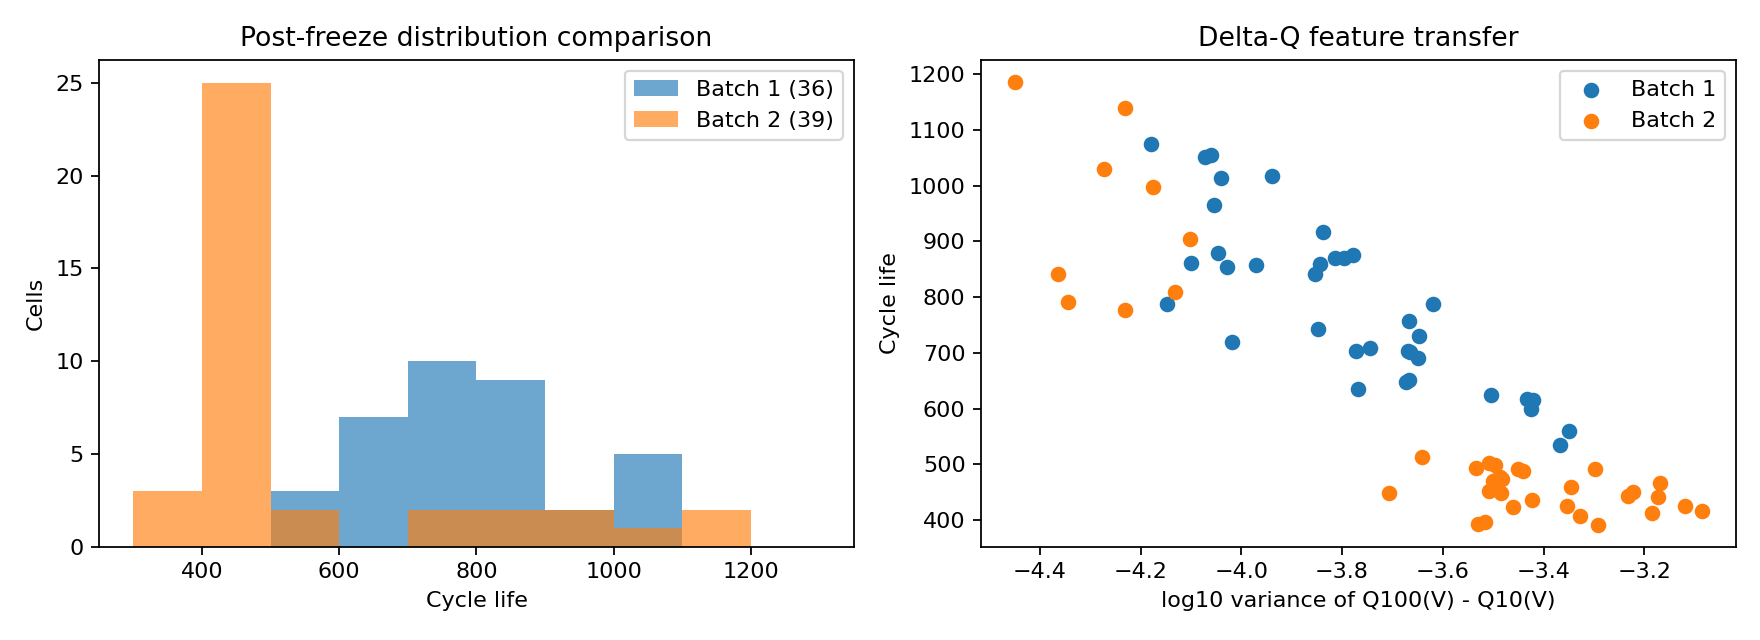

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.imshow(plt.imread(OUT / '03_batch_shift.png'))
plt.axis('off')
plt.show()

### 일부 이상치보다 넓게 나타나는 과대예측 편향

Batch 2 **39셀 중 36셀**을 과대예측했고 평균 부호 오차(예측−실제)는 **+133.1회**, 셀별 절대 오차율의 중앙값은 **30.41%**입니다. 일부 큰 오차만으로 평균 MAPE가 높아진 상황으로 설명하기 어렵습니다.

| group | n_cells | overpredicted_cells | underpredicted_cells | mean_signed_error_cycles | mae_cycles | median_ape_pct |
| --- | --- | --- | --- | --- | --- | --- |
| Batch 2 all | 39 | 36 | 3 | 133.134 | 141.752 | 30.410 |
| below_batch1_life_min | 30 | 30 | 0 | 146.086 | 146.086 | 32.508 |

Batch 1 최소 수명보다 짧은 **30셀 모두 과대예측**됐습니다. 이 집단에서는 MAE와 평균 부호 오차가 모두 146.1회입니다. 단수명 셀의 과대예측은 교체 지연 위험으로 이어질 수 있어 현재 모델을 단독 교체 시점 결정에 사용하기 어렵습니다. 표본 수만으로 원인을 설명하기보다 학습 수명 범위·배치 분포·피처와 수명의 관계를 먼저 점검해야 합니다.

`standard_structure`와 `below_batch1_life_min`은 **정확히 같은 30셀**입니다. 두 그룹 표는 동일 집합의 재표현이며 구조와 수명 범위의 독립적인 효과를 뒷받침하지 않습니다. 비교 근거는 `subgroup_overlap.csv`에 저장했습니다.


In [30]:
pd.read_csv(OUT / 'prediction_bias.csv')

group,n_cells,overpredicted_cells,underpredicted_cells,mean_signed_error_cycles,mae_cycles,median_ape_pct
Batch 2 all,39,36,3,133.134,141.752,30.410
below_batch1_life_min,30,30,0,146.086,146.086,32.508


In [31]:
pd.read_csv(OUT / 'subgroup_overlap.csv')

group_a,group_b,n_group_a,n_group_b,n_intersection,identical_cell_sets
standard_structure,below_batch1_life_min,30,30,30,True


### 오류 원인 가설을 반례와 함께 점검

입력 피처가 Batch 1 최솟값–최댓값 안인 **22셀의 MAPE 34.298%**가 범위 밖 **17셀의 21.247%**보다 큽니다. 따라서 **입력 범위 이탈만으로 Batch 2 오차를 설명할 수 없습니다.** 같은 입력 범위에서도 수명과의 관계가 배치마다 달라졌을 가능성, 정책·실험 조건의 교란을 함께 고려해야 합니다.

실제 수명이 학습 범위 밖이라는 구분은 정답을 본 뒤의 오류 분석용입니다. 배포 시에는 실제 수명을 모르므로 입력 분포·신규 정책·현장 라벨 수집으로 감시해야 합니다. 각 피처가 범위 안이라는 사실만으로 다변량 분포까지 같다고 보장되지 않습니다. `standard_structure` 30셀과 학습 최소 수명 미만 30셀은 동일 집합이므로 구조와 수명 범위의 효과를 분리할 수 없습니다.

| batch | group | n_cells | mape_pct | mae_cycles | rmse_cycles | overprediction_fraction |
| --- | --- | --- | --- | --- | --- | --- |
| 2 | all | 39 | 28.609 | 141.752 | 158.676 | 0.923 |
| 2 | inputs_inside_train_range | 22 | 34.298 | 159.572 | 169.872 | 0.955 |
| 2 | inputs_outside_train_range | 17 | 21.247 | 118.692 | 142.892 | 0.882 |
| 2 | life_below_train_min | 30 | 32.661 | 146.086 | 156.050 | 1.000 |
| 2 | life_above_train_max | 2 | 6.474 | 74.229 | 90.899 | 0.000 |
| 3 | all | 44 | 12.156 | 147.910 | 232.046 | 0.455 |
| 3 | inputs_inside_train_range | 23 | 8.627 | 76.840 | 94.529 | 0.478 |
| 3 | inputs_outside_train_range | 21 | 16.021 | 225.748 | 320.985 | 0.429 |
| 3 | life_above_train_max | 16 | 18.036 | 277.271 | 362.123 | 0.250 |




In [32]:
pd.read_csv(OUT / 'domain_metrics.csv')

batch,group,n_cells,mape_pct,mae_cycles,rmse_cycles,overprediction_fraction
2,all,39,28.609,141.752,158.676,0.923
2,inputs_inside_train_range,22,34.298,159.572,169.872,0.955
2,inputs_outside_train_range,17,21.247,118.692,142.892,0.882
2,life_below_train_min,30,32.661,146.086,156.050,1.000
2,life_above_train_max,2,6.474,74.229,90.899,0.000
3,all,44,12.156,147.910,232.046,0.455
3,inputs_inside_train_range,23,8.627,76.840,94.529,0.478
3,inputs_outside_train_range,21,16.021,225.748,320.985,0.429
3,life_above_train_max,16,18.036,277.271,362.123,0.250


### Batch 3 추가 검증·품질 민감도

동일 Batch 1 고정 모델로 44셀을 평가한 MAPE는 **12.156%**, Batch 3−Batch 2는 **-16.453%p**입니다. 이번 모델은 Batch 3보다 Batch 2의 짧은 수명에서 더 취약합니다. 배치별 난이도는 수명 분포·조건·모델에 따라 달라집니다.

| 구분 | 비교 항목 | MAPE (%) | 비고 |
| --- | --- | --- | --- |
| Train (Batch 1 CV) |  | 10.842 | 개발 Nested-CV (29셀); 외부 fold 검증오차 평균 |
| Valid (Batch 1 Hold-out) |  | 10.435 | 정책 분리 7셀; 개발 29셀로 학습 |
| Test (Batch 2) |  | 28.609 | Batch 1 36셀로 재학습한 고정 모델; 39셀 평가 |
|  | Gap (Train-Valid) | -0.407 | Valid − Train; (+): 오차 증가, 과적합 가능성 |
|  | Gap (Valid-Test) | 18.174 | Test − Valid; (+): 배치 간 일반화 저하 가능성 |
|  | Gap (Target-Test) | 19.509 | Test − 9.1%; 과제 Target 대비 참고 비교 |
| Test (Batch 3) |  | 12.156 | 추가 44셀; 동일 Batch 1 고정 모델 |
|  | Gap (Batch2-Batch3) | -16.453 | Batch 3 − Batch 2; (+): Batch 3 오차 증가 |
|  | Gap (Target-Test) | 3.056 | Batch 3 − 9.1%; 동일 조건 재현 아님 |

Gap (Train-Valid)은 Valid − Train, Gap (Valid-Test)은 Test − Valid로 계산합니다. Target Gap은 해당 배치 Test − 9.1, Batch2-Batch3 Gap은 Batch 3 − Batch 2이며 단위는 %p입니다.

수명 라벨이 있는 44셀 결과를 유지하고, [저자 LoadData.m](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)의 알려진 품질 제외 규칙을 적용한 40셀 결과도 민감도로 보고합니다. 원본 ID 23·32는 라벨 결측이고, 추가 점검 ID **2·37·42·43**은 원논문 중간 삭제 후 인덱스를 원본 0-based로 환산한 값입니다. 오차 크기를 보고 정한 제외 규칙이 아닙니다.

| scope | n_cells | mape_pct | mae_cycles | rmse_cycles |
| --- | --- | --- | --- | --- |
| all_finite_targets_44 | 44 | 12.156 | 147.910 | 232.046 |
| author_quality_filter_40 | 40 | 11.430 | 134.299 | 217.373 |

공통 전압축 2.0–3.5V·1,000점을 확인했고 ΔQ 분산은 곡선의 상수 원점 이동에 불변임을 검사했습니다. 이는 배치별 충전·방전 절차나 곡선 형태의 차이가 모두 교정됐다는 뜻은 아닙니다. 평균·최솟값에 동일한 불변성을 가정하지 않습니다.


In [33]:
batch3, audit3 = load_batch(3)
prediction3 = predict(final_model,batch3,config)
expected3 = pd.read_csv(OUT / 'predictions_all.csv')
expected3 = expected3[expected3.batch==3].set_index('cell_id').loc[batch3.cell_id]
np.testing.assert_allclose(prediction3,expected3.predicted_cycle_life)
pd.DataFrame([{'n_cells':len(batch3),**metrics(batch3.cycle_life,prediction3)}])

n_cells,mape_pct,mae_cycles,rmse_cycles
44,12.156,147.910,232.046


In [34]:
pd.read_csv(OUT / 'model_performance_with_batch3_formatted.csv').fillna('')

구분,비교 항목,MAPE (%),비고
Train (Batch 1 CV),,10.842,개발 Nested-CV (29셀); 외부 fold 검증오차 평균
Valid (Batch 1 Hold-out),,10.435,정책 분리 7셀; 개발 29셀로 학습
Test (Batch 2),,28.609,Batch 1 36셀로 재학습한 고정 모델; 39셀 평가
,Gap (Train-Valid),-0.407,"Valid − Train; (+): 오차 증가, 과적합 가능성"
,Gap (Valid-Test),18.174,Test − Valid; (+): 배치 간 일반화 저하 가능성
,Gap (Target-Test),19.509,Test − 9.1%; 과제 Target 대비 참고 비교
Test (Batch 3),,12.156,추가 44셀; 동일 Batch 1 고정 모델
,Gap (Batch2-Batch3),-16.453,Batch 3 − Batch 2; (+): Batch 3 오차 증가
,Gap (Target-Test),3.056,Batch 3 − 9.1%; 동일 조건 재현 아님


In [35]:
eda = pd.read_csv(OUT / 'eda_cell_features.csv')
print('곡선 원점 이동 후 분산 차이 최대:',eda.delta_variance_origin_invariance_error.max())
assert eda.delta_variance_origin_invariance_error.max() < 1e-12
pd.read_csv(OUT / 'batch3_quality_sensitivity.csv')

곡선 원점 이동 후 분산 차이 최대: 1.409462824231156e-18


scope,n_cells,mape_pct,mae_cycles,rmse_cycles
all_finite_targets_44,44,12.156,147.910,232.046
author_quality_filter_40,40,11.430,134.299,217.373


## 원논문 기반 추가 개발·비교

### 1. 원논문 설계를 실제 구현한 추가 실험

[Severson et al. (2019) 원논문](https://www.nature.com/articles/s41560-019-0356-8)의 본문 Table 1/2와 같은 논문의 Supplementary Table 1·4·5·6, Notes 1·4를 확인하고 **회귀 피처 확장, 초기 5회 이진 분류, 단·중·장 3분류, 그룹별 회귀 오차**를 실제 구현·학습·평가했습니다. 참고문헌은 원논문 한 편이며 보충자료는 그 논문의 일부입니다.

| 실험 | 관측 데이터 | 구현 | 평가 기준 |
| --- | --- | --- | --- |
| Variance 회귀 | 초기 100회 | log Var(Q100−Q10) 단일 피처, 선형 log 수명 회귀 | MAPE·MAE·RMSE |
| Discharge 회귀 | 초기 100회 | ΔQ 6개 + 용량 7개 = 13개 후보, Elastic Net | Batch 1 CV 선택, Batch 2/3 평가 |
| Full 회귀 | 초기 100회 | 위 13개 + 충전 시간·온도·IR 7개 = 20개 후보, Elastic Net | 같은 분할·전처리·선택 규칙 |
| Variance 이진 분류 | **초기 5회** | log Var(Q5−Q4), Logistic Regression | 수명 550회 경계, Macro-F1·Accuracy |
| Full 이진 분류 | **초기 5회** | 18개 후보, **L1 Logistic Regression** | 수명 550회 경계, Macro-F1·Accuracy·혼동행렬 |
| 단·중·장 분류 | 초기 100회 | 20개 후보, L2 Logistic Regression | <500 / 500–1,000 / >1,000회; 프로젝트 확장 |

새 분석은 회귀값을 구간으로 나누는 것에 그치지 않고 **분류기를 따로 학습**했습니다. 초기 5회 피처에는 6회 이후 자료가 들어가지 않습니다. 기존 회귀 예측의 구간화 결과도 `life_class_*.csv`로 보존해 실제 분류기와 구분합니다.

#### 피처 계산과 논문 대응

- ΔQ: 2.0–3.5V의 공통 1,000점에서 회귀는 Q100−Q10, 이진 분류는 Q5−Q4를 계산합니다. 최솟값·평균·표본 분산·왜도·첨도·2V 값을 보충자료의 log 절댓값 형태로 변환합니다. 분산은 논문 식의 **ddof=1**을 적용합니다.
- 용량: 2회부터 관측 끝까지의 선형 기울기·절편, Q2, 초기 최대 Q−Q2, 관측 끝 Q를 구현합니다. 91–100회의 기울기·절편은 100회 회귀에만 추가합니다.
- 충전·온도·IR: 충전 시간 평균, 최고·최저 온도, **원시 T(t)와 t의 사다리꼴 온도 적분**, IR2·최소 IR·끝 회차−2회 IR을 구현합니다. 온도 적분은 사이클 내부 시간을 이용해 적분한 뒤 관측 구간에서 합하며 단위는 °C·min입니다.
- 충전 시간은 회귀에서 논문 Note 1 식의 2–6회, 초기 5회 분류에서는 2–5회 유한 양수 값만 평균냅니다. 초기 5회 정의를 지키기 위해 6회 값은 제외합니다. 0 이하 IR은 결측, 결측 대치·표준화는 각 학습 fold 안에서 적합합니다.

원본 셀별 38개 계산 피처는 `paper_model_features.csv`, 온도 적분의 유효 회차 수는 `paper_feature_audit.csv`에 있습니다. 피처 추출은 `src/paper_models.py`의 `extract_window`·`read_features`로 재현합니다.


상단은 실제 550회 수명 그룹별 Q5−Q4 중앙값과 IQR, 하단은 셀별 초기 100회와 초기 5회 log 분산을 비교합니다. 서로 다른 관측 시점의 신호를 같은 피처로 간주하지 않고 각각 학습·평가했습니다. Batch 1 단수명 곡선은 1셀로 IQR이 0이며 집단 변동을 추정하지 않습니다.

### 2. 논문 피처군별 회귀 모델 비교와 최종 선택

| 이번 모델 | Batch 2 MAPE (%) | Batch 3 MAPE (%) | Nested-CV MAPE (%) | Hold-out MAPE (%) |
| --- | --- | --- | --- | --- |
| Variance | 28.559 | 12.814 | 9.064 | 10.426 |
| Discharge | 25.563 | 10.523 | 6.203 | 6.722 |
| Full | 30.283 | 10.041 | 10.158 | 7.679 |
| Selected | 25.563 | 10.523 | 6.203 | 6.722 |

Selected 행은 **Variance·Discharge·Full의 피처군과 파라미터를 내부 CV에서 함께 선택한 Nested-CV**입니다. 각 외부 검증 fold는 피처군 선택에도 사용하지 않습니다. 개발 29셀의 최종 선택 CV MAPE **5.351%**로 **Discharge / ElasticNet**, `alpha=0.01`, `l1_ratio=0.2`가 선택됐습니다. 최종 계수는 Batch 1 전체 36셀로 재학습하고 고정했습니다. Batch 2/3 점수로 모델을 바꾸지 않습니다.

기존 2피처 Ridge의 개발 선택 CV는 9.024%, Nested-CV는 10.842%였습니다. 새 설계는 논문의 후보 피처와 Elastic Net 선택을 반영했으며, 최종 Discharge 모델의 13개 후보 중 6개가 비영 계수로 남았습니다.

| 최종 비영 피처 | 표준화 log 수명 계수 |
| --- | --- |
| c100_dq_min_log | -0.041 |
| c100_dq_variance_log | -0.045 |
| c100_dq_kurtosis_log | -0.004 |
| c100_capacity_2 | 0.017 |
| c100_capacity_max_minus_2 | -0.023 |
| c100_capacity_end | 0.004 |

계수는 표준화 입력에 대한 log10 수명 계수입니다. 상관된 피처들의 조건부 계수이므로 물리적 인과 효과로 해석하지 않습니다. 후보·외부 fold별 선택·전처리 및 정책 분리 근거는 `paper_model_candidates.csv`, `paper_model_cv_folds.csv`, `paper_model_fold_manifest.csv`, `paper_models_config.json`에 있습니다.

### 3. 원논문 회귀 Table 1과 비교

| 원논문 모델 | Train MAPE (%) | Primary MAPE 전체 (제외 후) | Secondary MAPE (%) | Primary RMSE 전체 (제외 후) | Secondary RMSE (회) |
| --- | --- | --- | --- | --- | --- |
| Variance | 14.100 | 14.7 (13.2) | 11.400 | 138 (138) | 196 |
| Discharge | 9.800 | 13.0 (10.1) | 8.600 | 91 (86) | 173 |
| Full | 5.600 | 14.1 (7.5) | 10.700 | 118 (100) | 214 |

논문 Methods의 Mean percent error는 이번 MAPE와 같은 `100 × mean(|y−ŷ|/y)`입니다. 괄호는 논문이 특이한 Primary-test 셀 1개를 제외한 결과입니다. 과제의 **Target 9.1%는 논문 Abstract의 대표 성능**으로, Table 1의 Full Primary 전체값 14.1%와 구분합니다. 논문의 Train은 학습셋 성능이고 이번 Train은 Nested-CV 검증 평균입니다.

추가 최종 Discharge의 Batch 2 MAPE는 **25.563%**, Target Gap은 **+16.463%p**입니다. 기존 Ridge 28.609%에서 **3.046%p 감소**했지만 Target 9.1%에는 도달하지 못했습니다. Batch 2 MAE/RMSE는 **144.205 / 185.994회**입니다. 기존 Ridge 141.752 / 158.676회와 비교하면 **MAPE 개선이 MAE·RMSE 개선까지 뜻하지는 않습니다.** 짧은 수명을 더 크게 반영하는 MAPE로 선택한 결과와 큰 절대 오차를 함께 평가합니다.

원논문의 Primary test는 2017-05-12·2017-06-30 혼합 분할이고 과제 Batch 2는 2018-02-20입니다. 따라서 같은 정의의 지표·Target을 비교하되 동일 데이터 분할의 재현 성능으로 표시하지 않습니다. 이번 추가 실험은 기존 외부 결과를 확인한 이후의 분석이며 새 미사용 테스트셋을 확보한 실험은 아닙니다. 모델 파라미터 선택에는 Batch 1만 사용했습니다.

### 4. 장·단과 단·중·장 그룹 구성

| 기준 | Batch | 단수명 | 중간 | 장수명 |
| --- | --- | --- | --- | --- |
| 논문 장·단 | 1 | 1 | 해당 없음 | 35 |
| 논문 장·단 | 2 | 30 | 해당 없음 | 9 |
| 논문 장·단 | 3 | 1 | 해당 없음 | 43 |
| DAY 1 단·중·장 | 1 | 0 | 31 | 5 |
| DAY 1 단·중·장 | 2 | 28 | 8 | 3 |
| DAY 1 단·중·장 | 3 | 0 | 21 | 23 |

논문 이진 기준을 **단수명 ≤550 / 장수명 >550회**로 구현했습니다. 현재 실제값·예측값에 정확히 550회가 없어 등호 방향은 이번 결과에 영향을 주지 않습니다. 세 구간은 DAY 1 기준을 유지합니다. 동일한 '단수명'이라는 이름도 경계가 달라 두 그룹의 셀 수가 다릅니다.

### 5. 실제 학습한 초기 5회 분류: 논문과의 비교

| 원논문 분류기 | Train Accuracy (%) | Primary Accuracy (%) | Secondary Accuracy (%) |
| --- | --- | --- | --- |
| Variance classifier | 82.100 | 78.600 | 97.500 |
| Full classifier | 97.400 | 92.700 | 97.500 |

위는 본문 Table 2의 보고값을 그대로 옮긴 표입니다. 아래는 Full classifier의 보충자료 혼동행렬 셀 개수에서 별도로 재계산한 결과입니다.

| 원논문 분류기 | 분할 | 셀 수 | Accuracy (%) | Macro-F1 재계산 | 단수명 셀 | 단수명 Recall (%) |
| --- | --- | --- | --- | --- | --- | --- |
| Full classifier | Train | 38 | 97.368 | 0.974 | 20 | 95.000 |
| Full classifier | Primary test | 41 | 92.683 | 0.927 | 19 | 100.000 |
| Full classifier | Secondary test | 40 | 97.500 | 0.494 | 1 | 0.000 |
| Full classifier | Primary + Secondary test | 81 | 95.062 | 0.936 | 20 | 95.000 |

논문 Table 2의 Accuracy에 더해 **보충자료 Table 4·6의 혼동행렬에서 Macro-F1과 단수명 Recall을 재계산**했습니다. 이는 논문이 F1을 직접 보고했다는 뜻이 아닙니다. Full의 Primary+Secondary 81셀에서 Accuracy 95.062%가 한 자리 반올림으로 **95.1%**, 재계산 Macro-F1은 **0.935714**입니다. 과제의 Accuracy Target은 95.1%이고 F1 Target은 지정되지 않아 N/A로 둡니다. 재계산 F1은 별도 참고 비교에만 사용합니다. 보충자료 캡션은 Train 39셀로 적었지만 Full 혼동행렬의 합은 38셀입니다. Variance 혼동행렬도 캡션·본문 Accuracy와 일부 불일치합니다. 보고값을 임의로 수정하지 않고 `paper_classification_source_audit.csv`에 대조 결과를 저장했으며, F1은 명시된 혼동행렬 셀 개수로 계산했습니다.

| 태스크 | 피처군 | 평가 구분 | Macro-F1 | Accuracy (%) |
| --- | --- | --- | --- | --- |
| 초기 5회 이진 | Variance | Train (Batch 1 CV) | 0.490 | 96.429 |
| 초기 5회 이진 | Variance | Valid (Batch 1 Hold-out) | 0.500 | 100.000 |
| 초기 5회 이진 | Full | Train (Batch 1 CV) | 0.490 | 96.429 |
| 초기 5회 이진 | Full | Valid (Batch 1 Hold-out) | 0.500 | 100.000 |
| 초기 100회 3분류 | Full | Train (Batch 1 CV) | 0.324 | 75.446 |
| 초기 100회 3분류 | Full | Valid (Batch 1 Hold-out) | 0.667 | 100.000 |
| 초기 5회 이진 | Variance | Test (Batch 2) | 0.188 | 23.077 |
| 초기 5회 이진 | Full | Test (Batch 2) | 0.487 | 48.718 |
| 초기 100회 3분류 | Full | Test (Batch 2) | 0.106 | 17.949 |
| 초기 5회 이진 | Variance | Test (Batch 3) | 0.494 | 97.727 |
| 초기 5회 이진 | Full | Test (Batch 3) | 0.494 | 97.727 |
| 초기 100회 3분류 | Full | Test (Batch 3) | 0.461 | 70.455 |

단수명 재현율을 포함한 세부 결과는 `paper_model_class_recalls.csv`에 있습니다. 초기 5회 Full 모델은 L1 정규화 강도와 `class_weight=None/balanced`를 Batch 1 내부 Macro-F1로 선택합니다. class_weight 비교는 표본 불균형을 반영한 프로젝트 확장입니다. 이진 분류의 외부 CV 학습셋이 한 클래스뿐인 1개 fold는 그 학습 클래스만 예측하는 상수 모델을 적용하고 `constant_fallback`으로 기록했습니다. 검증 라벨로 학습 클래스를 보완하지 않습니다. 따라서 CV 평균은 이 fallback을 포함한 파이프라인의 결과입니다.

### 6. 장·단 이진 분류 성능표: 초기 5회 Full

| 구분 | F1-Score (macro) | Accuracy (%) | 비고 |
| --- | --- | --- | --- |
| Train (Batch 1 CV) | 0.490 | 96.429 | 29셀; 실제 학습 분류기 |
| Valid (Batch 1 Hold-out) | 0.500 | 100.000 | 7셀; 단수명 정답 0셀; 단수명 검증 불가 |
| Test (Batch 2) | 0.487 | 48.718 | 39셀; 실제 학습 분류기 |
| Gap (Train-Valid) | -0.010 | -3.571 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
| Gap (Valid-Test) | 0.013 | 51.282 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
| Gap (Target-Test) | — | 46.382 | Batch 2 기준; Accuracy Target 95.1%; F1 Target N/A |

#### 초기 5회 이진 분류: Batch 3 추가 양식

| 구분 | 비교 항목 | F1-Score (macro) | Accuracy (%) | 비고 |
| --- | --- | --- | --- | --- |
| Train (Batch 1 CV) |  | 0.490 | 96.429 | 29셀; 실제 학습 분류기 |
| Valid (Batch 1 Hold-out) |  | 0.500 | 100.000 | 7셀; 단수명 정답 0셀; 단수명 검증 불가 |
| Test (Batch 2) |  | 0.487 | 48.718 | 39셀; 실제 학습 분류기 |
|  | Gap (Train-Valid) | -0.010 | -3.571 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
|  | Gap (Valid-Test) | 0.013 | 51.282 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
|  | Gap (Target-Test) | — | 46.382 | Batch 2 기준; Accuracy Target 95.1%; F1 Target N/A |
| Test (Batch 3) |  | 0.494 | 97.727 | 44셀; 동일 고정 모델 |
|  | Gap (Batch2-Batch3) | -0.007 | -49.009 | Batch 2 점수 − Batch 3 점수 |
|  | Gap (Target-Test) | — | -2.627 | Batch 3 기준; Accuracy Target 95.1%; F1 Target N/A |

**Batch 2–3 Gap 해석:** Accuracy Gap은 **-49.009%p**, Macro-F1 Gap은 **-0.007**입니다. 음수는 Batch 3 점수가 더 높다는 뜻입니다. 그러나 단수명 셀은 Batch 2의 30셀에서 Batch 3의 1셀로 줄고, Batch 3 단수명 Recall은 **0.0%**입니다. 높은 Batch 3 Accuracy는 클래스 구성의 영향을 크게 받으며, Macro-F1과 혼동행렬까지 함께 봐야 합니다. 전체 Accuracy 개선을 단수명 식별이나 모든 배치의 일반화 개선으로 해석하지 않습니다.

F1은 고정된 2개 클래스의 **Macro-F1(0–1)**, Accuracy는 **%(0–100)**입니다. Train은 4개 Nested-CV 외부 fold 점수의 단순 평균입니다. 클래스가 실제·예측 모두 없으면 해당 클래스 F1을 0으로 포함(`zero_division=0`)합니다. Hold-out은 단수명 정답이 없어 Accuracy 100%가 단수명 식별의 검증을 뜻하지 않습니다.

Gap 방향·단위는 성능 결과의 공통 규칙을 따릅니다. 과제 지정 F1 Target이 없어 F1의 Target Gap은 N/A입니다. Hold-out 관련 두 Gap은 클래스 구성 차이를 포함한 참고 차이입니다.

### 7. 단·중·장 분류 성능표: 초기 100회 Full

| 구분 | F1-Score (macro) | Accuracy (%) | 비고 |
| --- | --- | --- | --- |
| Train (Batch 1 CV) | 0.324 | 75.446 | 29셀; 실제 학습 분류기 |
| Valid (Batch 1 Hold-out) | 0.667 | 100.000 | 7셀; 단수명 정답 0셀; 단수명 검증 불가 |
| Test (Batch 2) | 0.106 | 17.949 | 39셀; 실제 학습 분류기 |
| Gap (Train-Valid) | -0.343 | -24.554 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
| Gap (Valid-Test) | 0.561 | 82.051 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
| Gap (Target-Test) | — | — | Batch 2 기준; 3분류 Target N/A |

#### 단·중·장 분류: Batch 3 추가 양식

| 구분 | 비교 항목 | F1-Score (macro) | Accuracy (%) | 비고 |
| --- | --- | --- | --- | --- |
| Train (Batch 1 CV) |  | 0.324 | 75.446 | 29셀; 실제 학습 분류기 |
| Valid (Batch 1 Hold-out) |  | 0.667 | 100.000 | 7셀; 단수명 정답 0셀; 단수명 검증 불가 |
| Test (Batch 2) |  | 0.106 | 17.949 | 39셀; 실제 학습 분류기 |
|  | Gap (Train-Valid) | -0.343 | -24.554 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
|  | Gap (Valid-Test) | 0.561 | 82.051 | 단수명 Hold-out 0셀; 클래스 구성 차이를 포함한 참고 차이이며 단수명 식별력·동일 클래스 구성의 일반화 판단에 사용하지 않음 |
|  | Gap (Target-Test) | — | — | Batch 2 기준; 3분류 Target N/A |
| Test (Batch 3) |  | 0.461 | 70.455 | 44셀; 동일 고정 모델 |
|  | Gap (Batch2-Batch3) | -0.355 | -52.506 | Batch 2 점수 − Batch 3 점수 |
|  | Gap (Target-Test) | — | — | Batch 3 기준; 3분류 Target N/A |

**Batch 2–3 Gap 해석:** Accuracy Gap은 **-52.506%p**, Macro-F1 Gap은 **-0.355**입니다. 음수는 Batch 3 점수가 더 높다는 뜻입니다. <500회 단수명 셀은 Batch 1에 0셀, Batch 2에 28셀, Batch 3에 0셀입니다. Batch 2에는 학습에서 관측하지 못한 클래스가 다수 포함되지만 Batch 3에는 해당 클래스가 없습니다. 배치별 클래스 구성과 클래스별 Recall을 함께 설명하며, Batch 3 점수만으로 단수명 예측 능력을 검증했다고 주장하지 않습니다.

고정된 3개 클래스의 Macro-F1을 사용합니다. 3분류 Target은 원논문에 없어 `—`로 둡니다. Batch 1의 관측 클래스는 중간·장수명 두 개이며, 학습된 Logistic 모델은 이 관측 클래스에 대해 계수를 적합합니다. <500회 클래스는 학습셋에 없으므로 외부 셀의 단수명 Recall도 같이 제시합니다. 3분류를 이진 논문 Accuracy 95.1%와 동등한 실험으로 비교하지 않습니다.


행은 실제, 열은 예측 클래스입니다. Batch 2의 이진 단수명 **30셀 중 10셀**을 맞혀 Recall **33.3%**입니다. 3분류의 <500회 **28셀 중 0셀**을 맞혔습니다. Batch 3 이진 단수명 1셀의 Recall은 0.0%입니다. 높은 전체 Accuracy와 단수명 식별 성능을 구분해 해석합니다. 원논문에서도 Secondary-test 단수명은 1셀로, 혼동행렬과 재현율을 함께 보면 Accuracy의 구성 차이를 확인할 수 있습니다.

### 8. 최종 회귀를 같은 수명 기준으로 나눈 오류 분석

| 그룹 기준 | 평가 배치 | 실제 그룹 | 셀 수 | MAPE (%) | MAE (회) | 평균 예측−실제 (회) | 과대예측 셀 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 550회 이진 기준 | Test (Batch 2) | 단수명 ≤550 | 30 | 24.385 | 109.520 | 103.822 | 28 |
| 550회 이진 기준 | Test (Batch 2) | 장수명 >550 | 9 | 29.492 | 259.822 | 259.822 | 9 |
| 550회 이진 기준 | Test (Batch 3) | 단수명 ≤550 | 1 | 1.397 | 7.557 | -7.557 | 0 |
| 550회 이진 기준 | Test (Batch 3) | 장수명 >550 | 43 | 10.735 | 122.839 | -11.814 | 25 |
| 500/1,000회 세 구간 | Test (Batch 2) | 단수명 <500 | 28 | 24.184 | 107.486 | 101.382 | 26 |
| 500/1,000회 세 구간 | Test (Batch 2) | 중간 500–1,000 | 8 | 34.981 | 272.890 | 272.890 | 8 |
| 500/1,000회 세 구간 | Test (Batch 2) | 장수명 >1,000 | 3 | 13.318 | 143.754 | 143.754 | 3 |
| 500/1,000회 세 구간 | Test (Batch 3) | 단수명 <500 | 0 | — | — | — | 0 |
| 500/1,000회 세 구간 | Test (Batch 3) | 중간 500–1,000 | 21 | 10.516 | 86.666 | 69.142 | 17 |
| 500/1,000회 세 구간 | Test (Batch 3) | 장수명 >1,000 | 23 | 10.529 | 150.855 | -85.545 | 8 |

이는 실제 수명으로 나눈 사후 오류 분석입니다. 구간별 MAPE·MAE·과대예측을 함께 확인하고 0셀은 `—`로 둡니다. 논문은 이 세 구간별 회귀 오차를 보고하지 않아 위 구간에 별도의 논문 Target을 만들지 않습니다. 원논문과의 전체 MAPE 비교는 주 성능표에서 수행합니다.

추가 최종 모델은 Batch 2 **39셀 중 37셀**을 과대예측했습니다. 평균 예측−실제는 **+139.8회**, 오차율 중앙값은 **26.39%**입니다. Batch 1 중앙값 772.5회 기준선 MAPE **58.73%** 대비 새 모델 **25.56%**로 상대 오차가 **56.47% 감소**했습니다. 낮은 수명 셀의 교체 시점 판단에는 그룹별 편향도 함께 반영해야 합니다.

#### 최종 회귀 Batch 3의 품질 제외 민감도

| scope | n_cells | mape_pct | mae_cycles | rmse_cycles |
| --- | --- | --- | --- | --- |
| Batch 3 all eligible | 44 | 10.523 | 120.219 | 174.127 |
| Batch 3 author quality rule | 40 | 9.806 | 108.008 | 163.028 |

같은 저자 품질 규칙(원본 ID 2·37·42·43)을 추가 최종 모델에도 적용했습니다. 전체 44셀 평가를 유지하고 40셀 민감도를 나란히 보고하며, 오차 크기로 제외 대상을 정하지 않습니다.

### 추가 분석의 실행·계산 근거

```bash
python -m src.paper_models --batch3   # 원본 피처 추출, 실제 추가 학습과 평가
python -m src.report                  # 논문 비교표·그림·README·노트북 갱신
python -m src.verify_results          # 기존 모델 및 추가 실험의 계산·누수 검증
```

Batch 2 저장 수명 라벨의 원본 재검사는 `python -m src.submission_finalize --archive-dir archive`로 실행합니다. `python -m src.verify_results`는 원본 피처·미래 정보 배제·정책 분리·전처리·저장 예측·성능표와 Gap을 대조하고 DAY 2 노트북의 모든 코드 셀을 실행합니다. 검증에는 원본 MAT와 재생성한 로컬 모델이 필요하며, 공개 저장소의 CSV·그림·노트북 저장 출력은 별도로 열람할 수 있습니다.

전체 `python -m src.train --batch3`에도 추가 실험을 연결했습니다. 기존 Ridge 모델·예측·설정은 비교 기준으로 보존하며 해시 일치를 검사합니다. 논문 수치는 `paper_regression_metrics.csv`, `paper_classification_metrics.csv`, `paper_classification_confusion.csv`, 추가 실험은 `paper_model_*.csv`, 주 성능표는 `paper_selected_regression_performance.csv`, 이진·3분류 양식은 `paper_binary_550_performance.csv`·`paper_three_500_1000_performance.csv`에 있습니다.


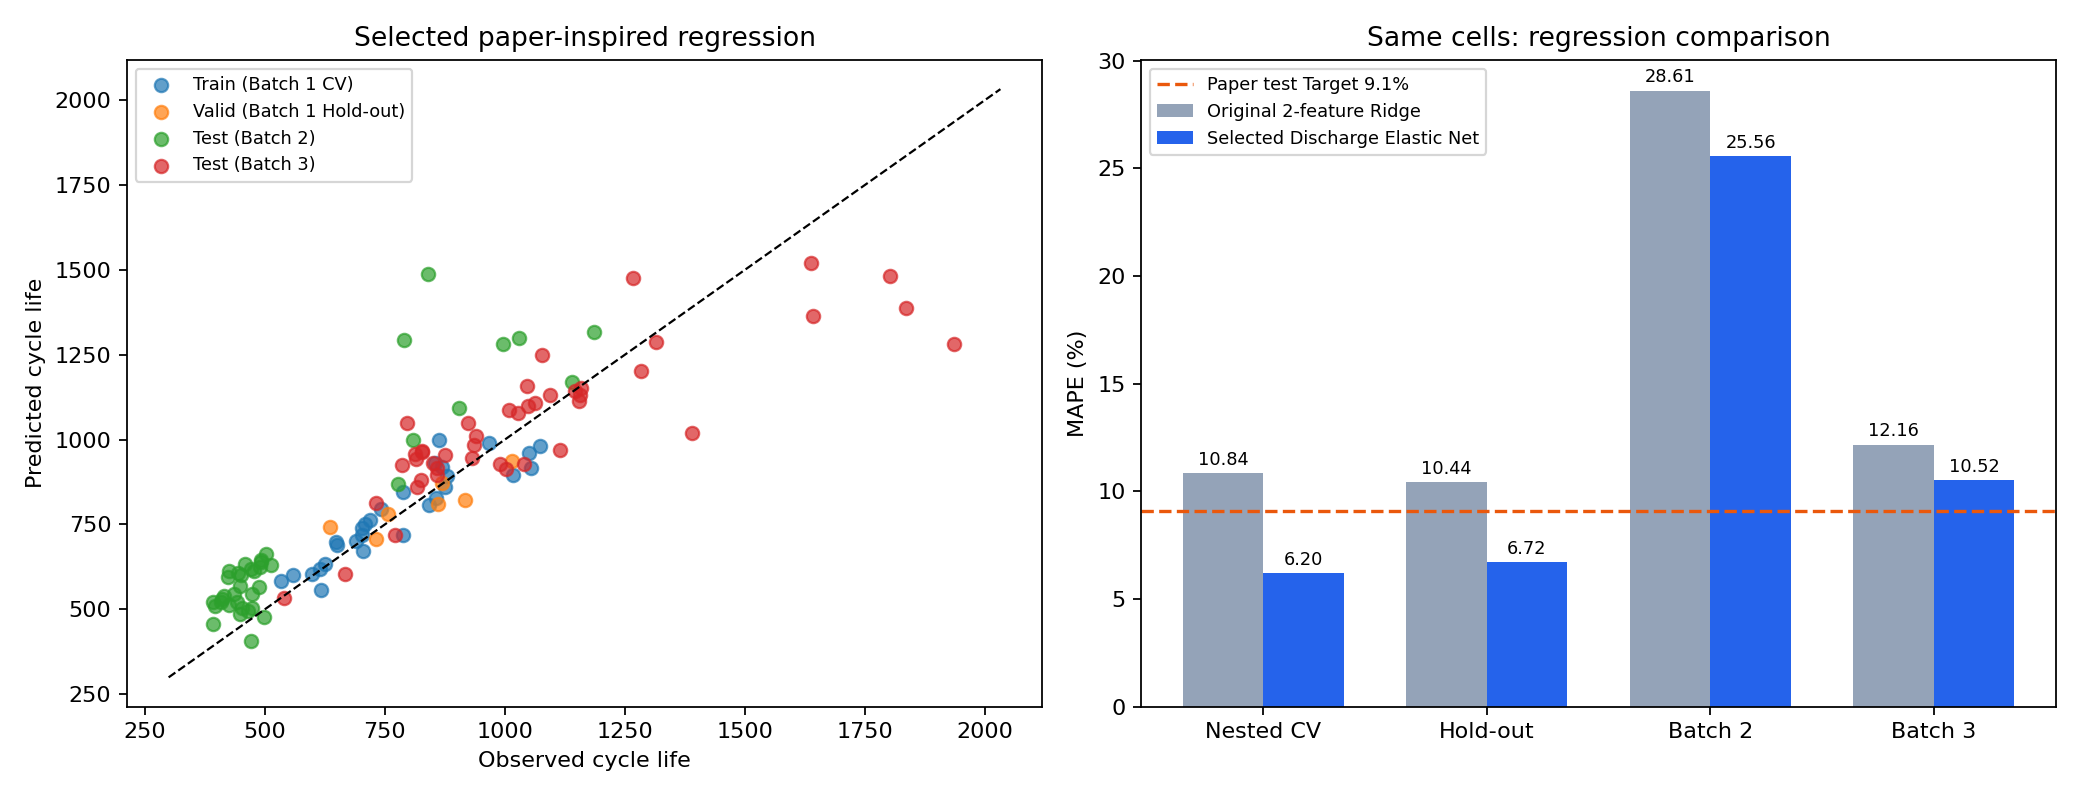

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '13_paper_regression_comparison.png'))
plt.axis('off')
plt.show()

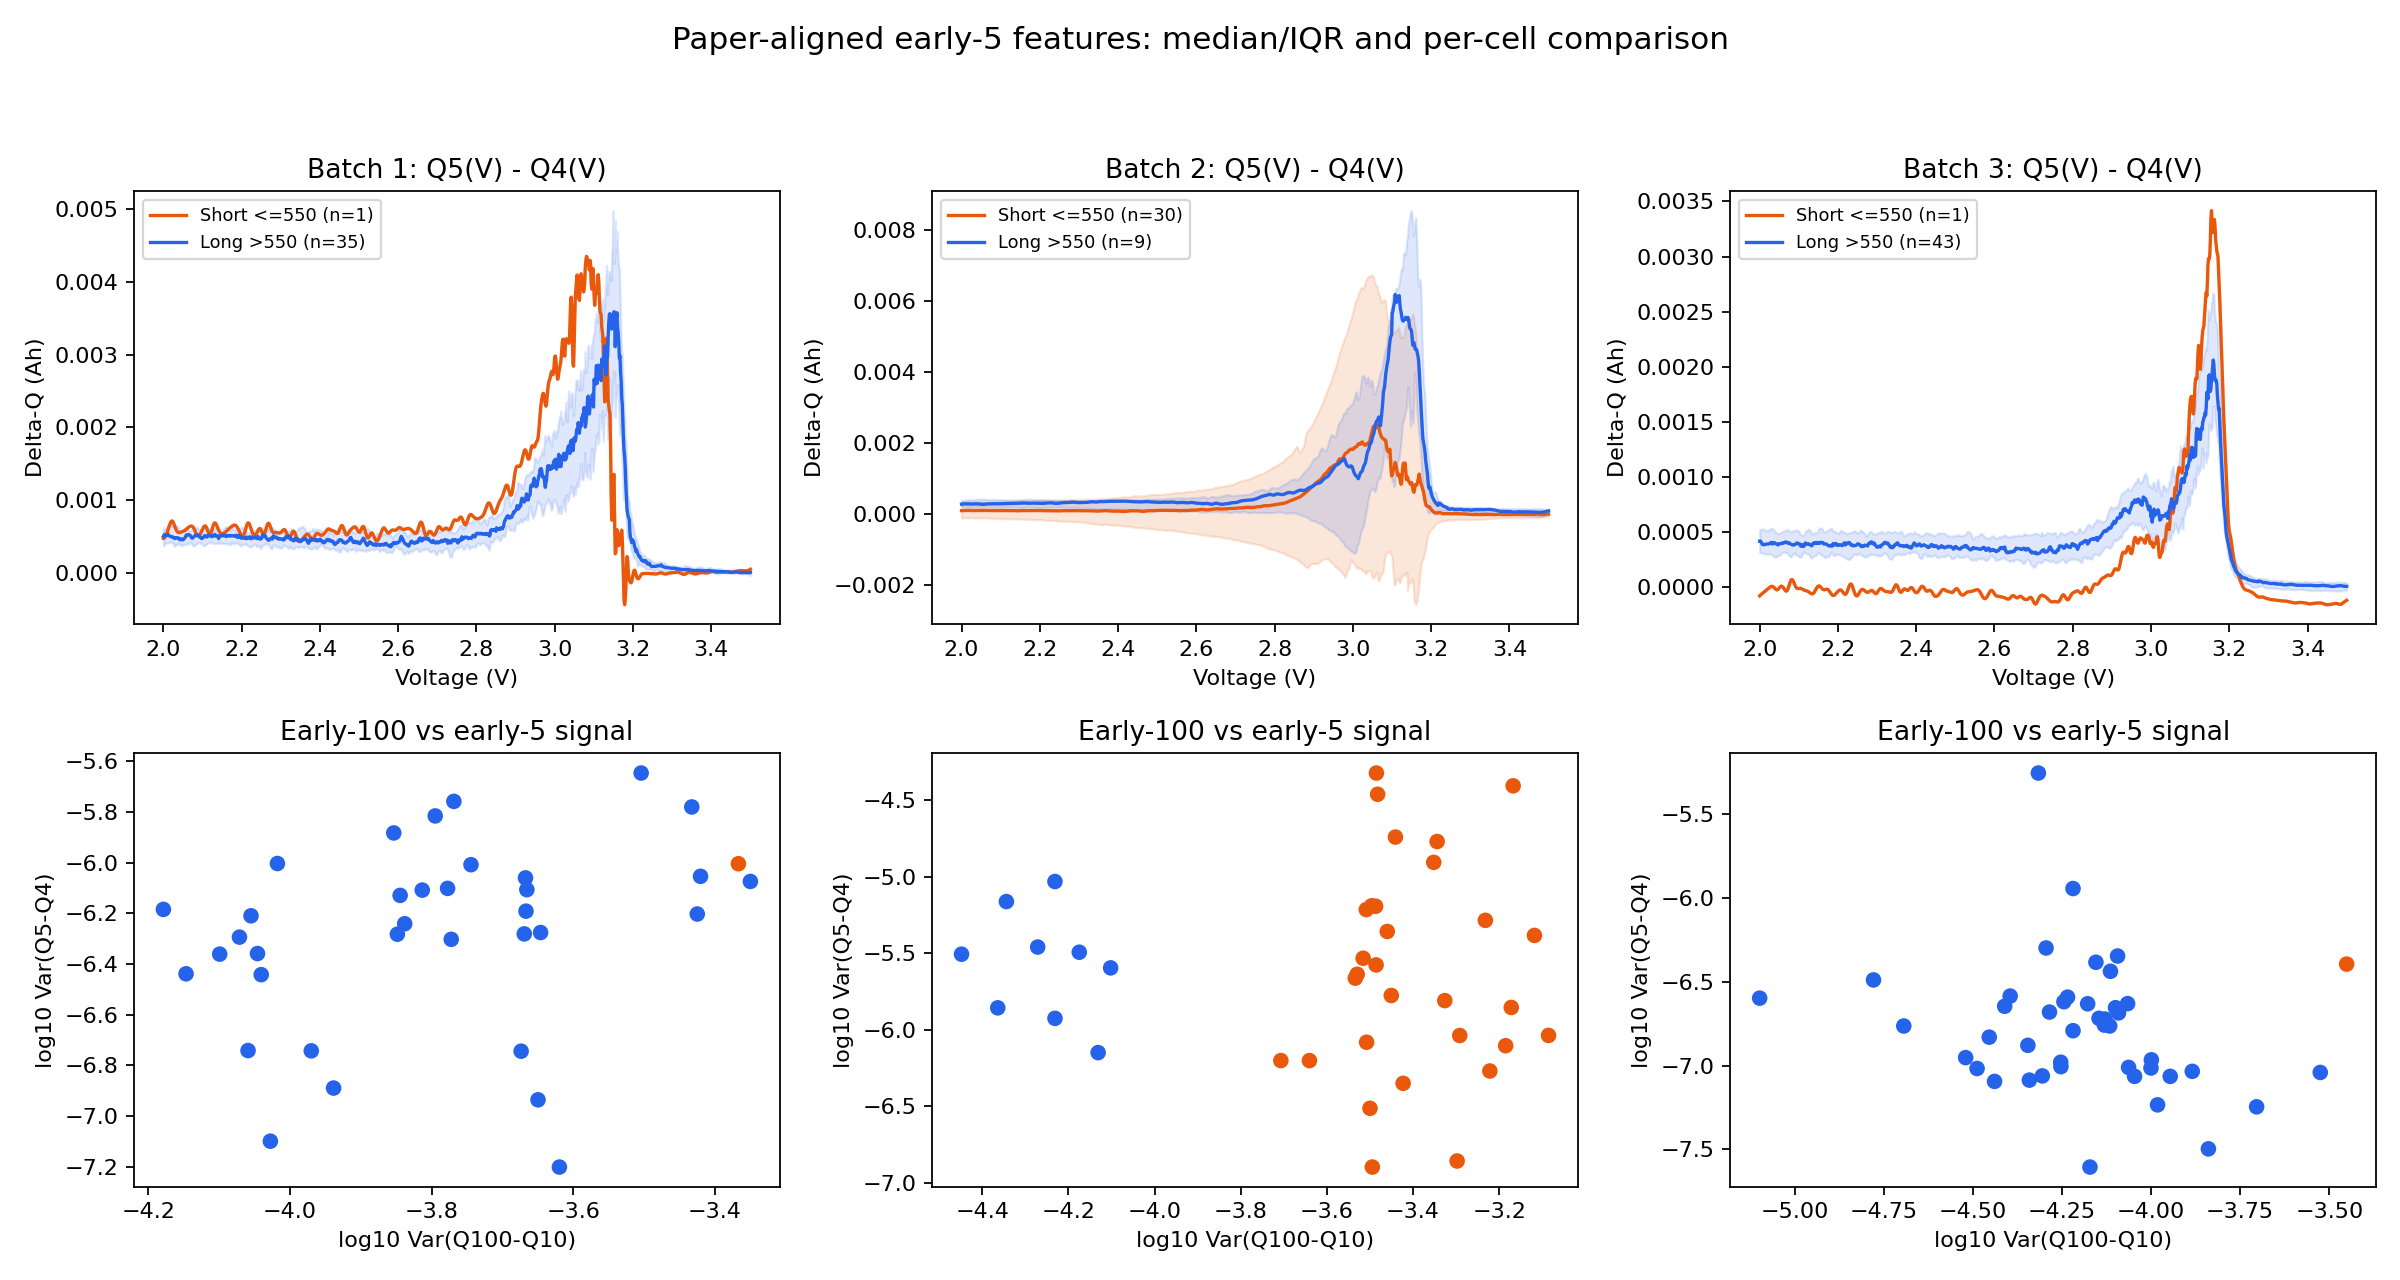

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '12_paper_early5_signal.png'))
plt.axis('off')
plt.show()

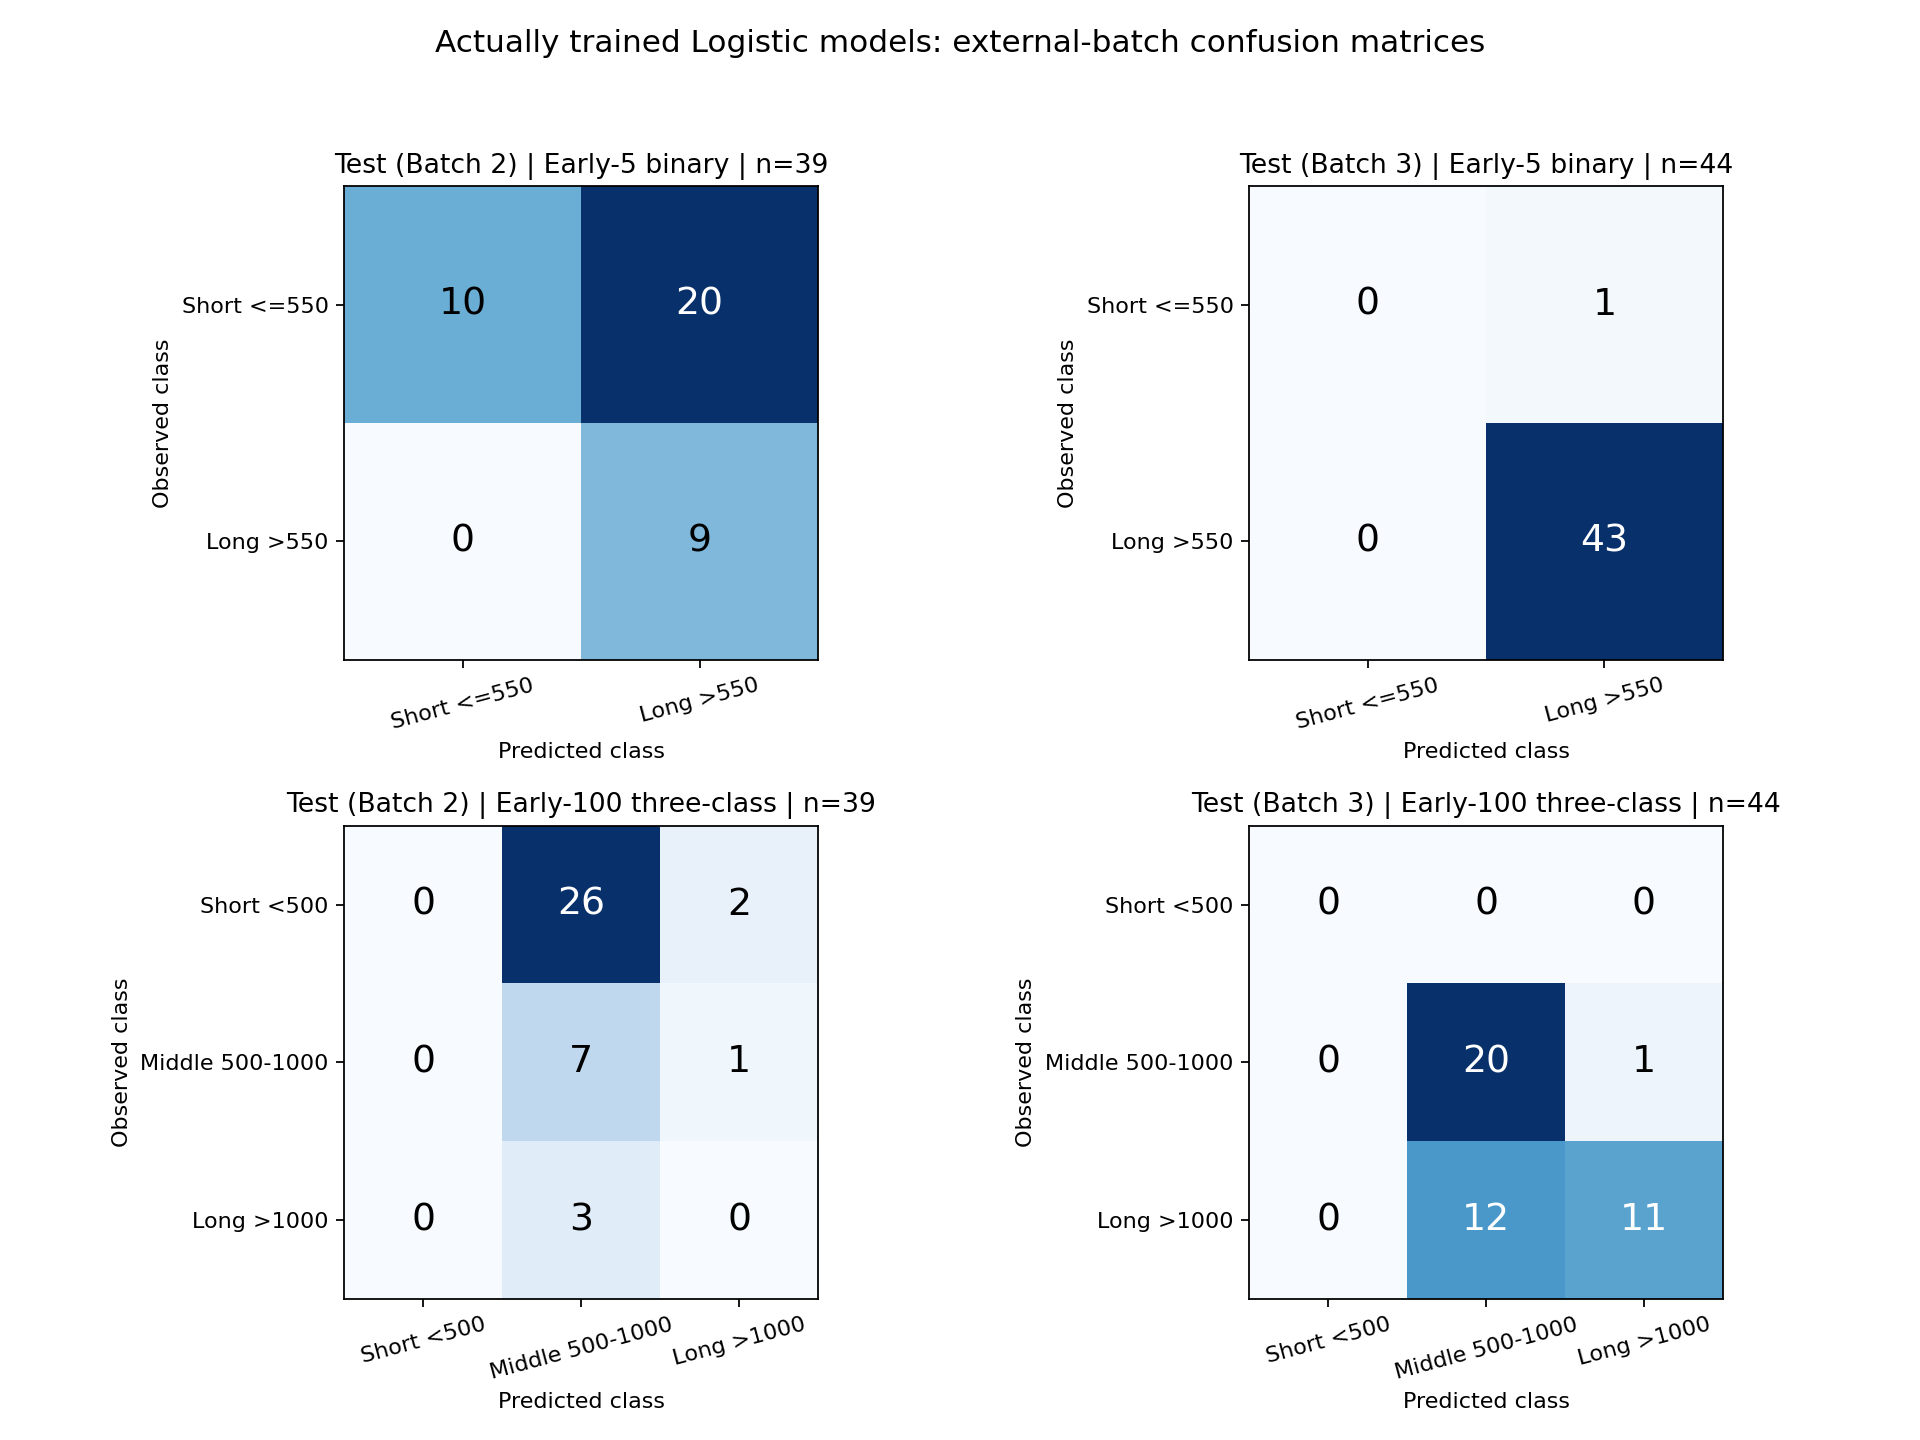

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.imshow(plt.imread(OUT / '11_paper_classifiers_confusion.png'))
plt.axis('off')
plt.show()

### 추가 학습 모델의 예측을 직접 재현

아래 셀은 저장된 논문 피처와 Batch 1 고정 설정으로 회귀·초기 5회 이진·3분류를 실제 재학습하고 외부 예측 일치를 검증합니다. 원본 피처부터 nested CV 전체 재현은 `python -m src.paper_models --batch3`로 실행합니다.

In [39]:
from src.paper_models import fit as fit_paper, evaluate as evaluate_paper
paper_config = json.loads((OUT / 'paper_models_config.json').read_text())
paper_features = pd.read_csv(OUT / 'paper_model_features.csv')
paper_predictions = pd.read_csv(OUT / 'paper_model_predictions.csv')
paper_b1 = paper_features[paper_features.batch==1].reset_index(drop=True)
paper_dev, paper_valid = development_split(paper_b1)
checks = []
for task, family in [('regression','Selected'), ('binary_550','Full'), ('three_500_1000','Full')]:
    record = next(r for r in paper_config if r['task']==task and r['family']==family)
    trained, selected_features, fallback = fit_paper(paper_b1,task,family,record['selected_config'])
    assert not fallback
    for number in sorted(paper_features.batch.unique()):
        if number==1: continue
        frame = paper_features[paper_features.batch==number]
        values, score = evaluate_paper(trained,selected_features,frame,task)
        expected = paper_predictions[(paper_predictions.task==task)&(paper_predictions.family==family)&(paper_predictions.batch==number)].set_index('cell_id').loc[frame.cell_id]
        np.testing.assert_allclose(values,expected.prediction)
        checks.append({'task':task,'family':family,'batch':number,**score})
pd.DataFrame(checks)

task,family,batch,mape_pct,mae_cycles,rmse_cycles,macro_f1,accuracy_pct
regression,Selected,2,25.563,144.205,185.994,NaN,NaN
regression,Selected,3,10.523,120.219,174.127,NaN,NaN
binary_550,Full,2,NaN,NaN,NaN,0.487,48.718
binary_550,Full,3,NaN,NaN,NaN,0.494,97.727
three_500_1000,Full,2,NaN,NaN,NaN,0.106,17.949
three_500_1000,Full,3,NaN,NaN,NaN,0.461,70.455


In [40]:
pd.read_csv(OUT / 'paper_selected_regression_performance.csv')

구분,MAPE (%),비고
Train (Batch 1 CV),6.203,29셀; 논문 피처군·파라미터를 Batch 1 내부 선택
Valid (Batch 1 Hold-out),6.722,7셀; 논문 피처군·파라미터를 Batch 1 내부 선택
Test (Batch 2),25.563,39셀; 논문 피처군·파라미터를 Batch 1 내부 선택
Gap (Train-Valid),0.519,Valid − Train; (+): 검증 오차 증가
Gap (Valid-Test),18.841,Test − Valid; (+): 외부 배치 오차 증가
Gap (Target-Test),16.463,Test − 9.1; 원논문 Target


In [41]:
pd.read_csv(OUT / 'paper_binary_550_performance.csv')

구분,F1-Score (macro),Accuracy (%),비고
Train (Batch 1 CV),0.490,96.429,29셀; 실제 학습 분류기
Valid (Batch 1 Hold-out),0.500,100.000,7셀; 실제 학습 분류기
Test (Batch 2),0.487,48.718,39셀; 실제 학습 분류기
Gap (Train-Valid),-0.010,-3.571,앞 단계 점수 − 뒤 단계 점수; (+): 점수 하락
Gap (Valid-Test),0.013,51.282,앞 단계 점수 − 뒤 단계 점수; (+): 점수 하락
Gap (Target-Test),0.449,46.382,Accuracy: 95.1 − Test; F1: 논문 혼동행렬 재계산값 − Test


In [42]:
pd.read_csv(OUT / 'paper_three_500_1000_performance.csv')

구분,F1-Score (macro),Accuracy (%),비고
Train (Batch 1 CV),0.324,75.446,29셀; 실제 학습 분류기
Valid (Batch 1 Hold-out),0.667,100.000,7셀; 실제 학습 분류기
Test (Batch 2),0.106,17.949,39셀; 실제 학습 분류기
Gap (Train-Valid),-0.343,-24.554,앞 단계 점수 − 뒤 단계 점수; (+): 점수 하락
Gap (Valid-Test),0.561,82.051,앞 단계 점수 − 뒤 단계 점수; (+): 점수 하락
Gap (Target-Test),NaN,NaN,3분류 Target·F1은 원논문에 없음; N/A


## 6. ESS 도메인 해석

초기 100사이클의 신호로 총수명을 추정해 셀 입고 선별, 점검 우선순위, 교체 예산 계획의 보조 지표로 활용할 수 있습니다. 이 모델의 목표는 총 Cycle Life이며 현재 시점의 RUL이나 화재 위험을 직접 예측하는 모델은 아닙니다. 과대예측은 교체 지연으로 이어질 수 있으므로 운영에서는 예측 불확실성과 보수적인 의사결정 기준이 필요합니다.

한계: 실험실 LFP/graphite 단일 셀과 특정 급속 충전 조건, 36셀 학습, Batch 1의 단수명 부재, 관측 종료 기준 차이, 세 배치 전체를 확인한 선행 EDA가 있습니다. 초기 용량 잡음은 범위 검사로 제외하고 센서 결측은 학습 fold 중앙값으로 대치하지만, 실 BESS의 달력 열화·온도 변화·부분 충방전·셀 불균형은 별도 검증이 필요합니다. 배포 전에는 현장 데이터와 다른 제조 배치, 프로토콜별 오차, 예측 구간, 입력 분포 변화 및 모니터링 기준을 검증해야 합니다.

| 의사결정 | 활용 | 추가 조건 |
| --- | --- | --- |
| 셀 선별·점검 우선순위 | 초기 신호로 상대 수명 비교 | 같은 화학계·현장 운전 조건 검증 |
| 교체 예산·정비 계획 | 총수명과 과대예측 위험 참고 | 셀별 예측 구간·보수적 기준·실제 SOH |
| 충전 운영 검토 | 정책별 오차·신규 정책 감시 | 관측 상관을 최적 C-rate의 인과 근거로 쓰지 않음 |

개선 우선순위: 단수명 개발 데이터 확보 → 새로운 배치·정책 검증 → 단순 기준선과 보조 피처 재비교 → 셀별 예측 구간·감시 기준. 현재 평가 데이터를 본 후의 개선 모델은 새로운 미사용 배치로 검증해야 합니다.

## 7. 평가항목 대응

| 평가항목 | 배점 | 확인할 구현·산출물 |
| --- | --- | --- |
| EDA | 50 | 30-ESSHealth-scratch.ipynb, DAY1 최종 보고서, 셀 audit·상관·분포·열화 |
| EDA → 전략 연결성 | 30 | 위 EDA→구현 연결표, 피처 세트별 CV 비교 |
| 모델링 전략 수립 | 20 | 회귀 선택 근거, 단일 피처 기준선, 소표본 정규화 |
| 전략 → 구현 반영 | 20 | src/features.py, CV 후보 비교 및 최종 계수 |
| Pipeline 개발 | 40 | src/preprocess.py·train.py, 정책 분할, fold 내부 대치·표준화, 고정 모델 저장 |
| 성능 리포팅 및 해석 | 20 | model_performance.csv, metrics.csv, Target Gap·조건 차이 설명 |
| 분석 결과 해석 | 20 | error_analysis.csv, subgroup_metrics.csv, 잔차·배치 비교 그래프, ESS 활용·한계 |

## 재학습 및 검증

프로젝트 루트 터미널에서 `python -m src.train`, `python -m src.verify_results`를 실행하면 결과를 재생성하고 분할·성능표·모델 저장·미래 정보 배제를 확인합니다. 노트북에는 원본 피처 추출과 고정 설정의 재학습·평가 셀도 포함하며 전체 후보 탐색은 위 명령으로 수행합니다.

## 참고문헌

- Severson et al. (2019). Data-driven prediction of battery cycle life before capacity degradation. *Nature Energy*, 4, 383–391. [원논문](https://www.nature.com/articles/s41560-019-0356-8).

## 수행자

- 최유정(울산 3반 U104), 개인 수행: EDA, 모델 전략 수립, 피처 엔지니어링, 파이프라인·모델 개발, Batch 2·3 성능 평가, 오류 분석 및 보고서 작성 전 과정.

## 계산 근거·평가항목·재현성

| 평가항목 | 배점 | 직접 근거 | 산출물 |
| --- | --- | --- | --- |
| EDA | 50 | 분포·열화·ΔQ·정책·상관·VIF를 원본 재계산 | eda_distribution / degradation_evidence / eda_correlations / eda_vif |
| EDA → 전략 연결성 | 30 | 관측→시사점→설계→코드→검증 연결표 | 노트북 1–3절 |
| 모델링 전략 수립 | 20 | 논문 피처군·Elastic Net·초기 5회 Logistic·3분류·Batch 1 선택 | paper_model_candidates / paper_models_config / 기존 cv_results |
| 전략 → 구현 반영 | 20 | 100회 이내 피처·타깃 변환·실제 선택 모델 | features.py / model_coefficients / 노트북 직접 추출 |
| Pipeline 개발 | 40 | 원본→정책 분리→fold 내부 전처리→선택→재학습→평가 | train.py / 직접 재현 셀 / provenance / verify_results.py |
| 성능 리포팅 및 해석 | 20 | 회귀·이진·3분류 지정 양식·원논문 혼동행렬 F1·Gap | paper_selected_regression_performance / paper_binary_550_performance / paper_three_500_1000_performance |
| 분석 결과 해석 | 20 | 과대예측 편향·동일 하위집단 확인·입력 범위 반례·ESS 해석 | prediction_bias / subgroup_overlap / domain_metrics / ESS 의사결정표 |

이 표는 자체 점수가 아니라 평가자가 확인할 계산 근거의 위치입니다.

### 재현 근거

원본 파일 SHA-256·크기·고정 모델 해시·실행 패키지는 `provenance.json`에 있습니다. 학습 환경 Python 3.11.15, 추가 검증 환경 Python 3.11.15에서 같은 scikit-learn 1.6.1 모델의 예측을 검산했습니다.

```bash
python -m src.train --batch3       # 원본부터 전체 파이프라인
python -m src.diagnostics --batch3 # 기존 고정 모델의 추가 검증
python -m src.verify_results      # 결과·누수·코드 셀 검증
```

`--batch3`를 생략하면 필수 Batch 1/2만 수행합니다. 추가 모델 선택 없이 고정 모델을 평가합니다. 원본·모델 해시 일치도 검사합니다.


In [43]:
provenance = json.loads((OUT / 'provenance.json').read_text())
print('고정 모델 SHA-256:',provenance['model_sha256'])
print('실행 패키지:',provenance['packages'])
pd.DataFrame(provenance['sources'])

고정 모델 SHA-256: 494a514a77a8fc0ebc1134f5de88abd0c8adfb2b23ffac7dce7d6abd3350b2eb
실행 패키지: {'numpy': '2.0.2', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'h5py': '3.14.0', 'matplotlib': '3.9.4', 'nbformat': '5.10.4', 'joblib': '1.5.3', 'scipy': '1.17.1'}


batch,filename,bytes,sha256
1,2017-05-12_batchdata_updated_struct_errorcorrect.mat,3025320241,9d928ab978f0e3c70b31cb833a749fedd35094d01af76475d69b40aa3497f5ba
2,2018-02-20_batchdata_updated_struct_errorcorrect.mat,2022599329,3487db505ad08b6c805f41dd0560e73b54077c76aca04f706f06e2356ccf7845
3,2018-04-12_batchdata_updated_struct_errorcorrect.mat,3236690412,62c30e413b63e6144720e016deed3661fac8468641794a5807b123fe84717998


## 제출 전 추가 검증

Batch 2 유효 39셀의 저장 라벨을 배열 위치가 아닌 원본 사이클 번호로 대조했습니다. 정확 일치 39셀, 불일치 0셀, 미도달 0셀입니다. 최초 도달 이후 재상승 기록이 2셀에 있지만 최초 도달 정의와 저장 라벨은 일치합니다. 허용 오차·라벨 변경·셀 제외를 적용하지 않았습니다. 아래 표는 셀별 검사와 추가 참고 비교의 실제 계산 결과입니다. 과제 F1 Target Gap은 N/A이며 논문에서 재계산한 F1 차이는 참고 비교입니다.

In [44]:
pd.read_csv(OUT / 'batch2_cycle_life_audit.csv')

,batch,cell_id,stored_cycle_life,first_qd_le_088_cycle,crossing_minus_stored_cycles,not_reached,exact_match,status,first_crossing_qd_ah,previous_valid_cycle,previous_valid_qd_ah,last_recorded_cycle,last_qd_ah,recovered_above_088_after_first_crossing,n_nonfinite_pairs,threshold_ah,cycle_number_source
0,2,0,477.0,477.0,0.0,False,True,exact_match,0.878808,476.0,0.880302,496.0,0.826613,False,0,0.88,summary.cycle; never array position
1,2,1,491.0,491.0,0.0,False,True,exact_match,0.876985,490.0,0.881487,513.0,0.828482,False,0,0.88,summary.cycle; never array position
2,2,2,424.0,424.0,0.0,False,True,exact_match,0.877919,423.0,0.880777,439.0,0.827009,False,0,0.88,summary.cycle; never array position
3,2,3,499.0,499.0,0.0,False,True,exact_match,0.877732,498.0,0.880924,517.0,0.825510,False,0,0.88,summary.cycle; never array position
4,2,4,444.0,444.0,0.0,False,True,exact_match,0.877557,443.0,0.881735,464.0,0.827127,False,0,0.88,summary.cycle; never array position
5,2,5,416.0,416.0,0.0,False,True,exact_match,0.878485,415.0,0.884386,445.0,0.826154,False,0,0.88,summary.cycle; never array position
6,2,6,393.0,393.0,0.0,False,True,exact_match,0.879843,392.0,0.880479,409.0,0.829404,False,0,0.88,summary.cycle; never array position
7,2,7,777.0,777.0,0.0,False,True,exact_match,0.879855,776.0,0.882178,806.0,0.826481,False,0,0.88,summary.cycle; never array position
8,2,8,904.0,904.0,0.0,False,True,exact_match,0.878980,903.0,0.881429,947.0,0.825586,False,0,0.88,summary.cycle; never array position
9,2,9,791.0,791.0,0.0,False,True,exact_match,0.878668,790.0,0.880705,819.0,0.826105,False,0,0.88,summary.cycle; never array position


In [45]:
pd.read_csv(OUT / 'paper_binary_secondary_comparison.csv')

,evaluation,n_cells,accuracy_pct,macro_f1,n_short,n_short_correct,short_recall_pct
0,논문 Full Secondary,40,97.500000,0.493671,1,0,0.0
1,이번 Batch 3 전체,44,97.727273,0.494253,1,0,0.0
2,이번 Batch 3 저자 품질 규칙,40,97.500000,0.493671,1,0,0.0


In [46]:
pd.read_csv(OUT / 'paper_binary_f1_reference_comparison.csv')

,evaluation,project_macro_f1,paper_pooled_reference_macro_f1,reference_minus_project_f1,purpose
0,이번 Batch 2,0.486842,0.935714,0.448872,reference comparison only; not an assignment F...
1,이번 Batch 3 전체,0.494253,0.935714,0.441461,reference comparison only; not an assignment F...
2,이번 Batch 3 저자 품질 규칙,0.493671,0.935714,0.442043,reference comparison only; not an assignment F...


In [47]:
pd.read_csv(OUT / 'paper_selected_structure_errors.csv')

,partition,structure,n_cells,mape_pct,mae_cycles,mean_signed_error_cycles,observed_life_min,observed_life_max,structure_source
0,Test (Batch 2),standard,30,24.384604,109.519710,103.822327,392.0,514.0,policy contains newstructure; otherwise standard
1,Test (Batch 2),newstructure,9,29.491506,259.822269,259.822269,777.0,1186.0,policy contains newstructure; otherwise standard
2,Test (Batch 3),standard,0,NaN,NaN,NaN,NaN,NaN,policy contains newstructure; otherwise standard
3,Test (Batch 3),newstructure,44,10.522705,120.219090,-11.717024,541.0,1935.0,policy contains newstructure; otherwise standard


In [48]:
pd.read_csv(OUT / 'paper_selected_vif.csv')

,scope,feature_set,feature,n_cells,r_squared,vif,imputation
0,Batch 1 full fit,Discharge 13 candidates,c100_dq_min_log,36,0.999258,1346.825132,median fitted on this Batch 1 scope; diagnosti...
1,Batch 1 full fit,Discharge 13 candidates,c100_dq_mean_log,36,0.998271,578.460089,median fitted on this Batch 1 scope; diagnosti...
2,Batch 1 full fit,Discharge 13 candidates,c100_dq_variance_log,36,0.998768,811.888421,median fitted on this Batch 1 scope; diagnosti...
3,Batch 1 full fit,Discharge 13 candidates,c100_dq_skew_log,36,0.637520,2.758775,median fitted on this Batch 1 scope; diagnosti...
4,Batch 1 full fit,Discharge 13 candidates,c100_dq_kurtosis_log,36,0.835265,6.070354,median fitted on this Batch 1 scope; diagnosti...
5,Batch 1 full fit,Discharge 13 candidates,c100_dq_2v_log,36,0.982593,57.447484,median fitted on this Batch 1 scope; diagnosti...
6,Batch 1 full fit,Discharge 13 candidates,c100_capacity_slope,36,0.998963,963.986294,median fitted on this Batch 1 scope; diagnosti...
7,Batch 1 full fit,Discharge 13 candidates,c100_capacity_intercept,36,0.999902,10183.170908,median fitted on this Batch 1 scope; diagnosti...
8,Batch 1 full fit,Discharge 13 candidates,c100_late_slope,36,0.999896,9597.767475,median fitted on this Batch 1 scope; diagnosti...
9,Batch 1 full fit,Discharge 13 candidates,c100_late_intercept,36,0.999974,38962.049760,median fitted on this Batch 1 scope; diagnosti...
